In [1]:
!pip install -q pandas numpy matplotlib seaborn plotly scikit-learn scipy joblib lightgbm catboost xgboost Jinja2

In [2]:
import os, re, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
os.makedirs("image", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
print("Created image/ and artifacts/ folders.")

Created image/ and artifacts/ folders.


In [4]:
def clean_filename(title):
    return re.sub(r"_+", "_", re.sub(r"\s+", "_", re.sub(r'[\\/*?:"<>|]', "", str(title)).strip())).lower()

def save_plot(title, folder="image", dpi=300, show=True):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, clean_filename(title) + ".png")
    plt.title(title, fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")
    if show: plt.show()
    plt.close()

def save_plotly(fig, title, folder="image"):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, clean_filename(title) + ".html")
    fig.write_html(path)
    print(f"Saved: {path}")

In [5]:
file_path = "Data/final_selected_features.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (12469, 19)


In [6]:
display(df.head())

,Academic_Engagement,Assignment_Attendance_Index,Study_Assignment_Index,Study_Attendance_Index,AssignmentCompletion,Attendance_Normalized,Age,Attendance,StudyHours,OnlineCourses,StudyHours_Normalized,LearningStyle,Motivation_Study_Index,StressLevel,Online_Learning_Activity,Participation_Rate,Digital_Learning_Index,Motivation,FinalGrade
0,61.436364,37.76,0.254773,0.276364,59,0.64,19,64,19,8,0.431818,2,0.0,1,8,0.5,0.46,0,3
1,63.836364,57.60,0.388636,0.276364,90,0.64,23,64,19,16,0.431818,3,0.0,1,16,0.0,0.62,0,2
2,54.636364,42.88,0.289318,0.276364,67,0.64,28,64,19,19,0.431818,1,0.0,1,38,0.0,0.88,0,0
3,61.436364,37.76,0.254773,0.276364,59,0.64,19,64,19,8,0.431818,2,0.0,1,8,1.0,0.46,0,3
4,63.836364,57.60,0.388636,0.276364,90,0.64,23,64,19,16,0.431818,3,0.0,1,16,0.5,0.62,0,2


In [7]:
display(df.tail())

,Academic_Engagement,Assignment_Attendance_Index,Study_Assignment_Index,Study_Attendance_Index,AssignmentCompletion,Attendance_Normalized,Age,Attendance,StudyHours,OnlineCourses,StudyHours_Normalized,LearningStyle,Motivation_Study_Index,StressLevel,Online_Learning_Activity,Participation_Rate,Digital_Learning_Index,Motivation,FinalGrade
12464,82.236364,62.00,0.681818,0.422727,100,0.62,22,62,30,2,0.681818,2,0.340909,2,4,1.0,0.44,1,1
12465,71.036364,44.64,0.490909,0.422727,72,0.62,23,62,30,12,0.681818,3,0.340909,1,24,1.0,0.64,1,2
12466,79.000000,72.00,0.400000,0.450000,80,0.90,23,90,22,0,0.500000,3,0.250000,0,0,0.5,0.40,1,2
12467,57.000000,45.00,0.250000,0.450000,50,0.90,29,90,22,16,0.500000,2,0.250000,2,32,0.0,0.92,1,2
12468,66.745455,56.76,0.150000,0.195455,66,0.86,18,86,10,8,0.227273,2,0.227273,2,16,1.0,0.76,2,1


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12469
Columns: 19


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12469 entries, 0 to 12468
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Academic_Engagement          12469 non-null  float64
 1   Assignment_Attendance_Index  12469 non-null  float64
 2   Study_Assignment_Index       12469 non-null  float64
 3   Study_Attendance_Index       12469 non-null  float64
 4   AssignmentCompletion         12469 non-null  int64  
 5   Attendance_Normalized        12469 non-null  float64
 6   Age                          12469 non-null  int64  
 7   Attendance                   12469 non-null  int64  
 8   StudyHours                   12469 non-null  int64  
 9   OnlineCourses                12469 non-null  int64  
 10  StudyHours_Normalized        12469 non-null  float64
 11  LearningStyle                12469 non-null  int64  
 12  Motivation_Study_Index       12469 non-null  float64
 13  StressLevel                

In [10]:
display(df.dtypes.to_frame("Data Type"))

,Data Type
Academic_Engagement,float64
Assignment_Attendance_Index,float64
Study_Assignment_Index,float64
Study_Attendance_Index,float64
AssignmentCompletion,int64
Attendance_Normalized,float64
Age,int64
Attendance,int64
StudyHours,int64
OnlineCourses,int64


In [11]:
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

,Missing Values
Academic_Engagement,0
Assignment_Attendance_Index,0
Study_Assignment_Index,0
Study_Attendance_Index,0
AssignmentCompletion,0
Attendance_Normalized,0
Age,0
Attendance,0
StudyHours,0
OnlineCourses,0


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3


In [13]:
num_cols = df.select_dtypes(include=np.number).columns
inf_counts = np.isinf(df[num_cols]).sum()
print("Total infinite values:", inf_counts.sum())
display(inf_counts[inf_counts > 0].to_frame("Infinite Values"))

Total infinite values: 0


,Infinite Values


In [14]:
df = df.replace([np.inf, -np.inf], np.nan)
print("Infinite values converted to NaN.")

Infinite values converted to NaN.


In [15]:
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_columns if constant_columns else "None")

Constant columns: None


In [16]:
duplicate_columns = []
for i, a in enumerate(df.columns):
    for b in df.columns[i+1:]:
        if df[a].equals(df[b]): duplicate_columns.append((a, b))
print("Duplicated column pairs:")
print(duplicate_columns if duplicate_columns else "None")

Duplicated column pairs:
None


In [17]:
display(df.describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
Academic_Engagement,12469.0,69.046695,8.887030,42.572727,62.681818,69.272727,75.400000,94.418182
Assignment_Attendance_Index,12469.0,59.787372,14.627411,30.000000,48.910000,58.240000,69.920000,99.000000
Study_Assignment_Index,12469.0,0.339468,0.124742,0.059091,0.248864,0.325000,0.420000,0.990000
Study_Attendance_Index,12469.0,0.365795,0.124353,0.069318,0.274091,0.359318,0.448864,0.859773
AssignmentCompletion,12469.0,74.515358,14.657687,50.000000,62.000000,74.000000,87.000000,100.000000
Attendance_Normalized,12469.0,0.802392,0.114690,0.600000,0.700000,0.800000,0.900000,1.000000
Age,12469.0,23.529152,3.510956,18.000000,20.000000,24.000000,27.000000,29.000000
Attendance,12469.0,80.239233,11.469028,60.000000,70.000000,80.000000,90.000000,100.000000
StudyHours,12469.0,20.034405,6.049485,5.000000,16.000000,20.000000,24.000000,44.000000
OnlineCourses,12469.0,9.872404,6.114025,0.000000,5.000000,10.000000,15.000000,20.000000


In [18]:
target = "FinalGrade"
if target not in df.columns: raise ValueError("FinalGrade is missing.")
print("Target:", target)
print("Classes:", sorted(df[target].dropna().unique()))
print("Number of classes:", df[target].nunique())

Target: FinalGrade
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Number of classes: 4


In [19]:
if "ExamScore" in df.columns: raise ValueError("ExamScore must not be used.")
print("ExamScore is absent; no exam-score target will be synthesized.")

ExamScore is absent; no exam-score target will be synthesized.


In [20]:
target_counts = df[target].value_counts().sort_index()
display(target_counts.to_frame("Students"))

,Students
FinalGrade,
0,3401
1,2943
2,3221
3,2904


In [21]:
target_pct = df[target].value_counts(normalize=True).sort_index().mul(100)
display(target_pct.round(2).to_frame("Percentage"))

,Percentage
FinalGrade,
0,27.28
1,23.60
2,25.83
3,23.29


Saved: image\finalgrade_class_distribution.png


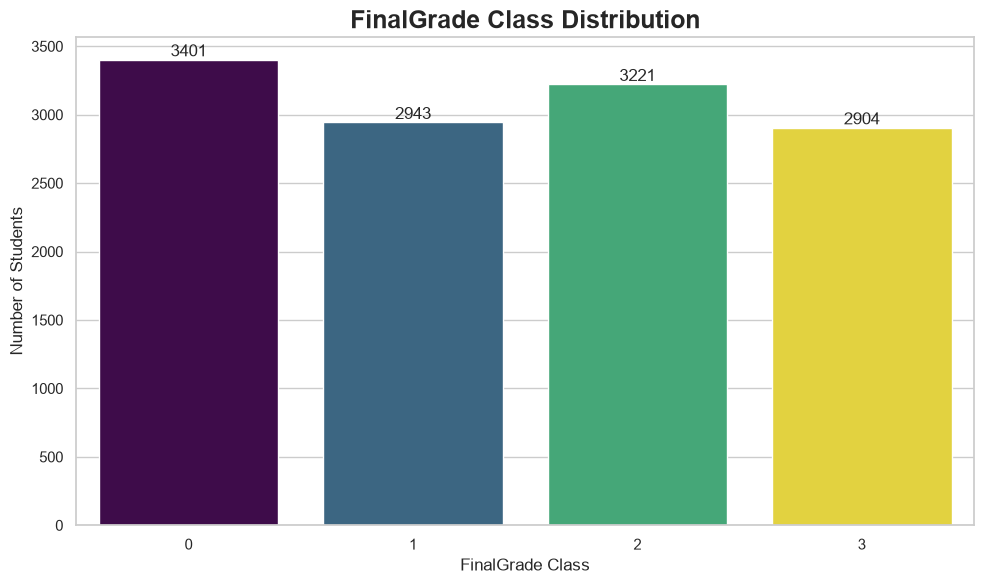

In [22]:
title = "FinalGrade Class Distribution"
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x=target, hue=target, palette="viridis", legend=False)
for c in ax.containers: ax.bar_label(c)
plt.xlabel("FinalGrade Class"); plt.ylabel("Number of Students")
save_plot(title)

Saved: image\finalgrade_class_percentage_distribution.png


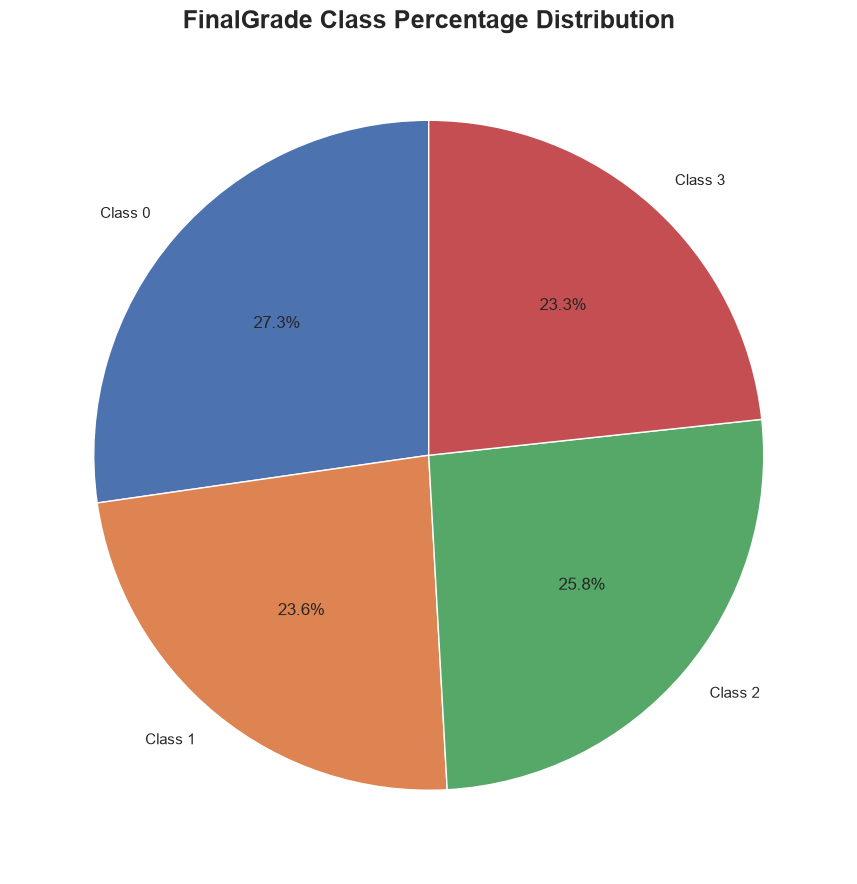

In [23]:
title = "FinalGrade Class Percentage Distribution"
plt.figure(figsize=(9,9))
plt.pie(target_counts.values, labels=[f"Class {x}" for x in target_counts.index], autopct="%1.1f%%", startangle=90)
save_plot(title)

In [24]:
X = df.drop(columns=[target])
y = df[target].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12469, 18)
y shape: (12469,)


In [25]:
assert target not in X.columns
print("Validation passed: FinalGrade is not an input feature.")

Validation passed: FinalGrade is not an input feature.


In [26]:
categorical_features = [c for c in ["LearningStyle", "StressLevel", "Motivation"] if c in X.columns]
print(categorical_features)

['LearningStyle', 'StressLevel', 'Motivation']


In [27]:
numerical_features = [c for c in X.columns if c not in categorical_features]
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Academic_Engagement', 'Assignment_Attendance_Index', 'Study_Assignment_Index', 'Study_Attendance_Index', 'AssignmentCompletion', 'Attendance_Normalized', 'Age', 'Attendance', 'StudyHours', 'OnlineCourses', 'StudyHours_Normalized', 'Motivation_Study_Index', 'Online_Learning_Activity', 'Participation_Rate', 'Digital_Learning_Index']
Categorical: ['LearningStyle', 'StressLevel', 'Motivation']


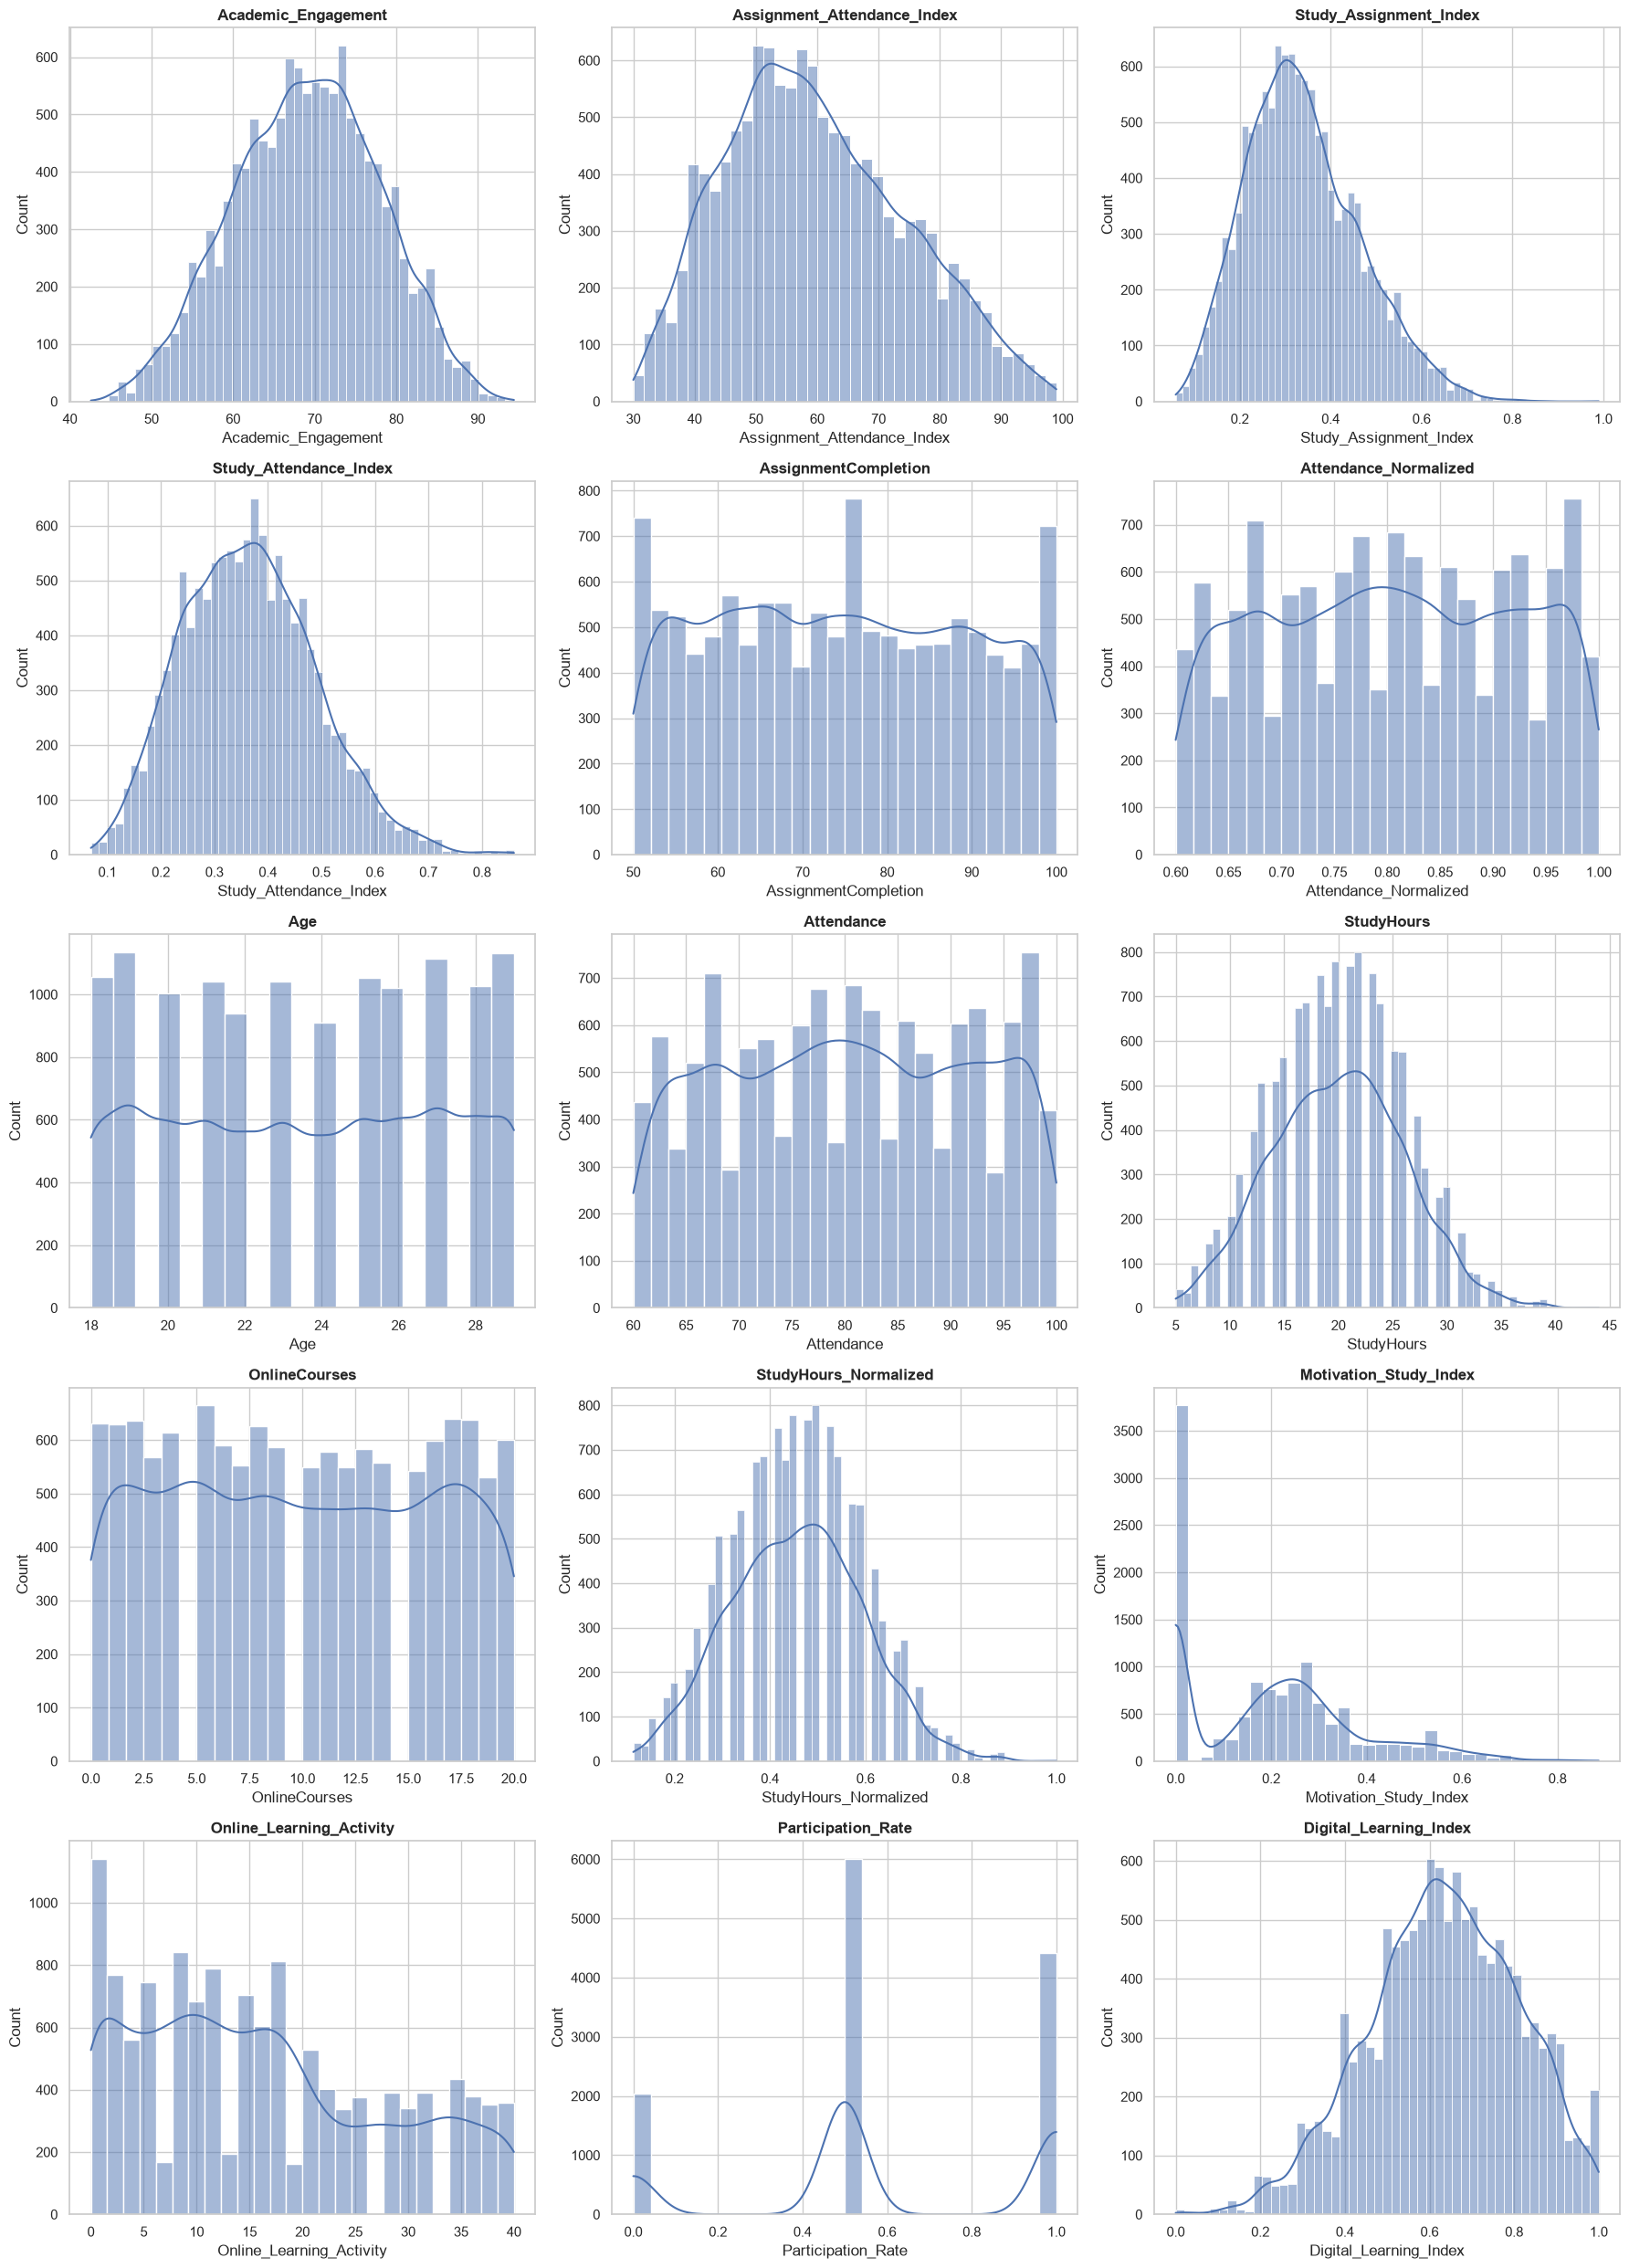

Saved: image/numerical_feature_distributions.png


In [28]:
ncols = 3
nrows = int(np.ceil(len(numerical_features)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows)); axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numerical_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col, fontsize=12, fontweight="bold")
for ax in axes[len(numerical_features):]: ax.axis("off")
plt.tight_layout(); plt.savefig("image/numerical_feature_distributions.png", dpi=300, bbox_inches="tight"); plt.show(); plt.close()
print("Saved: image/numerical_feature_distributions.png")

Saved: image\academic_engagement_distribution_by_finalgrade.png


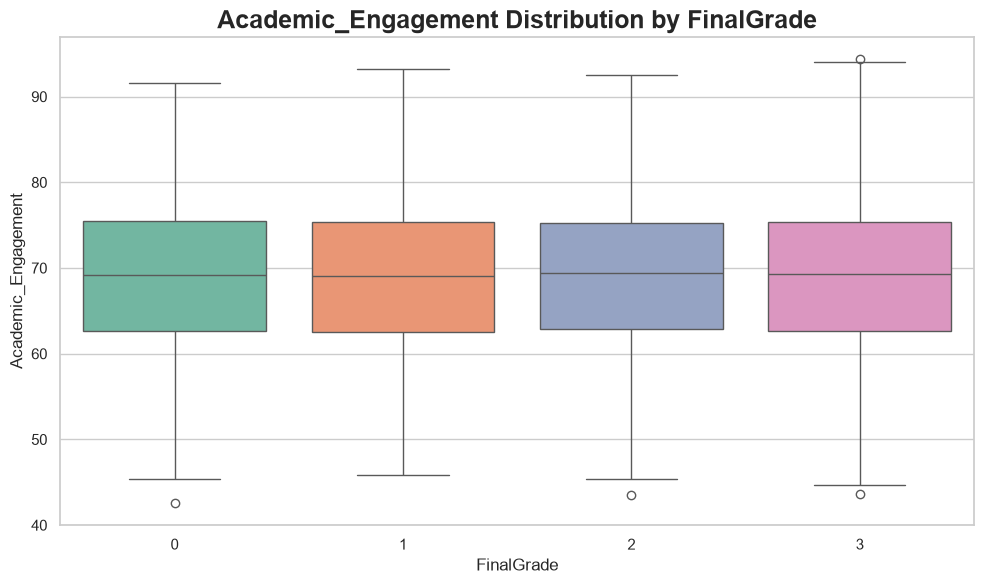

Saved: image\assignment_attendance_index_distribution_by_finalgrade.png


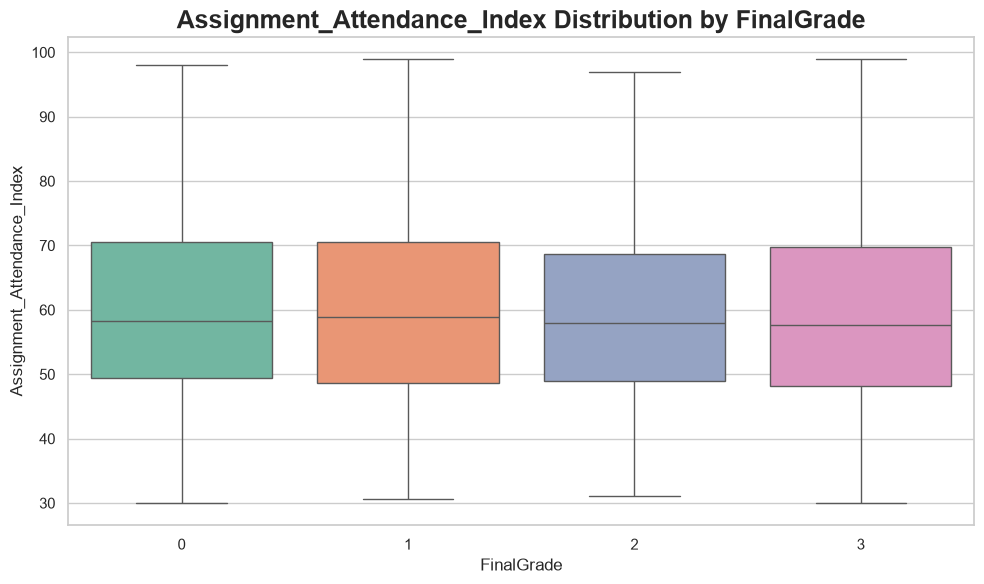

Saved: image\study_assignment_index_distribution_by_finalgrade.png


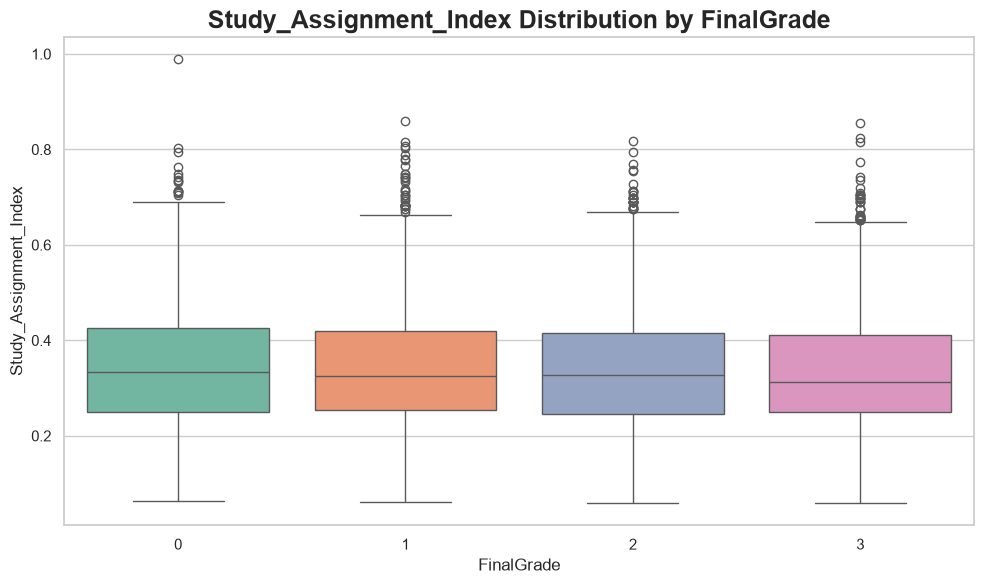

Saved: image\study_attendance_index_distribution_by_finalgrade.png


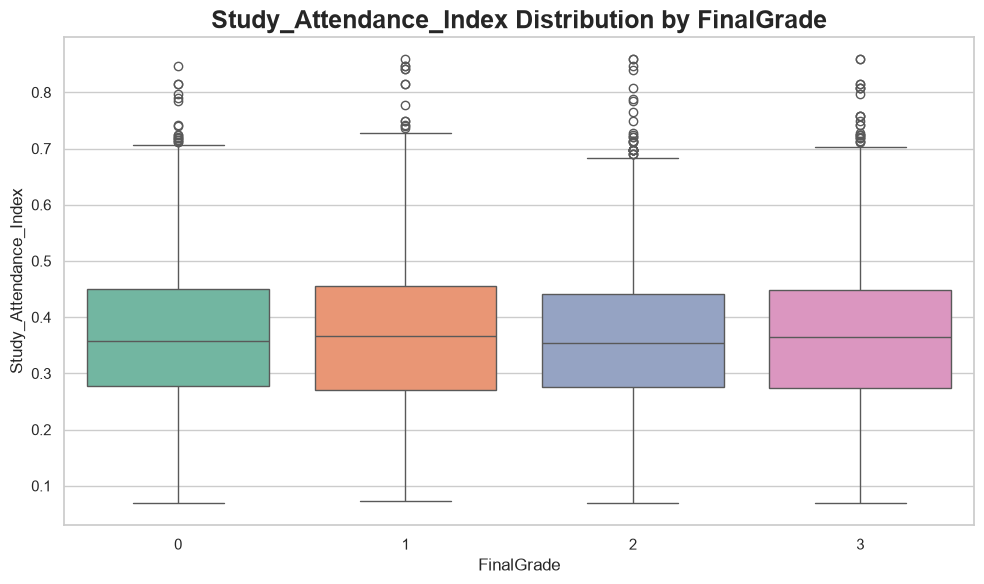

Saved: image\assignmentcompletion_distribution_by_finalgrade.png


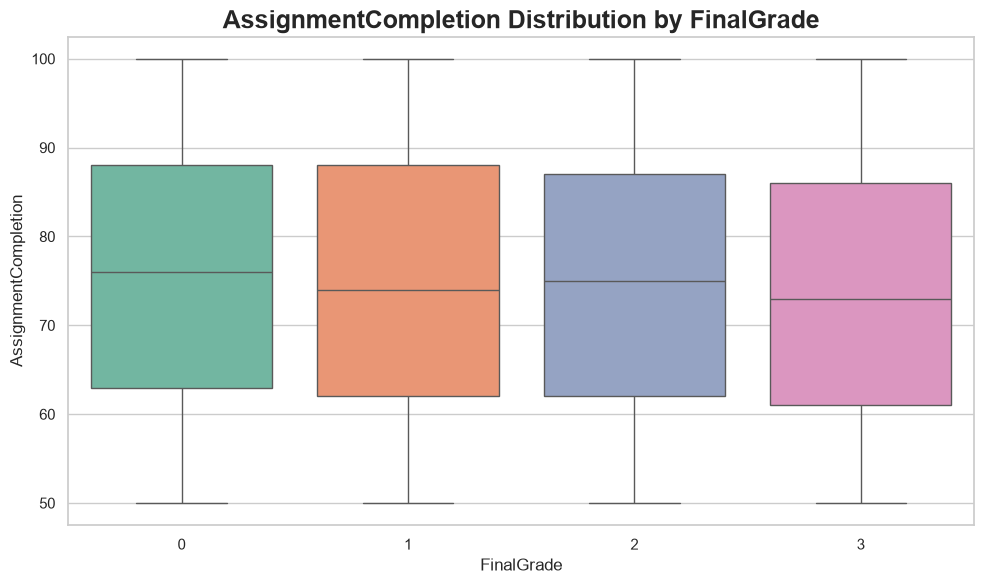

Saved: image\attendance_normalized_distribution_by_finalgrade.png


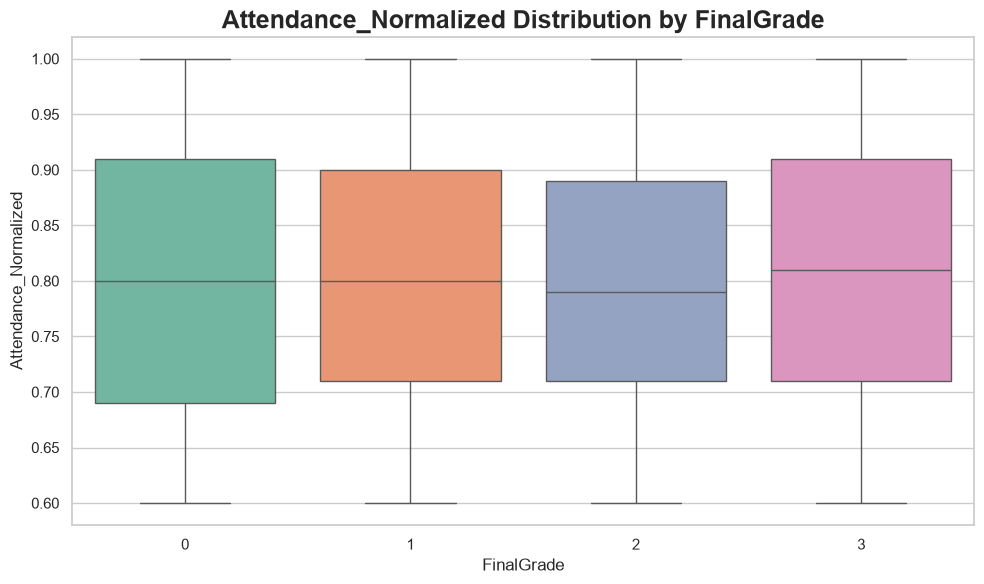

Saved: image\age_distribution_by_finalgrade.png


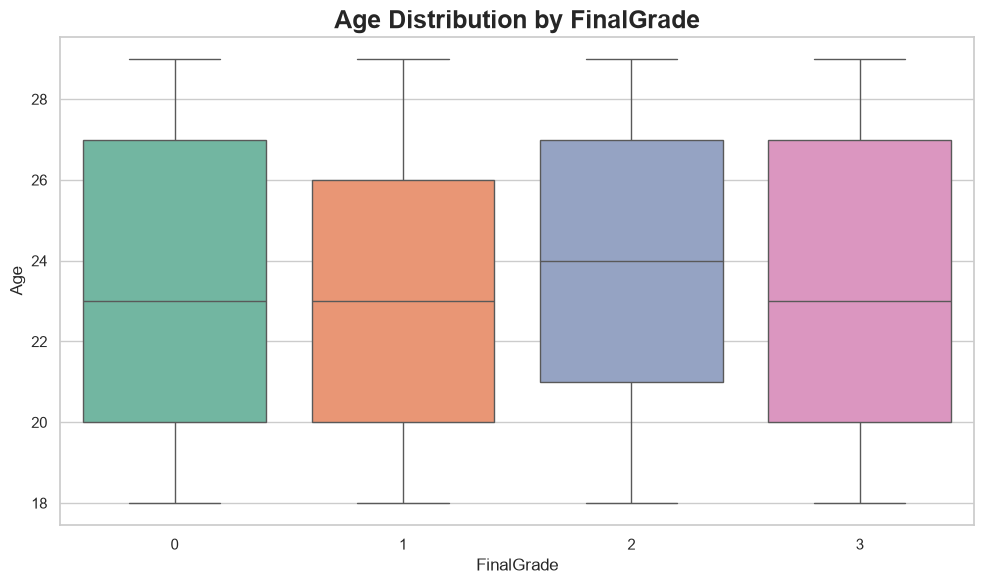

Saved: image\attendance_distribution_by_finalgrade.png


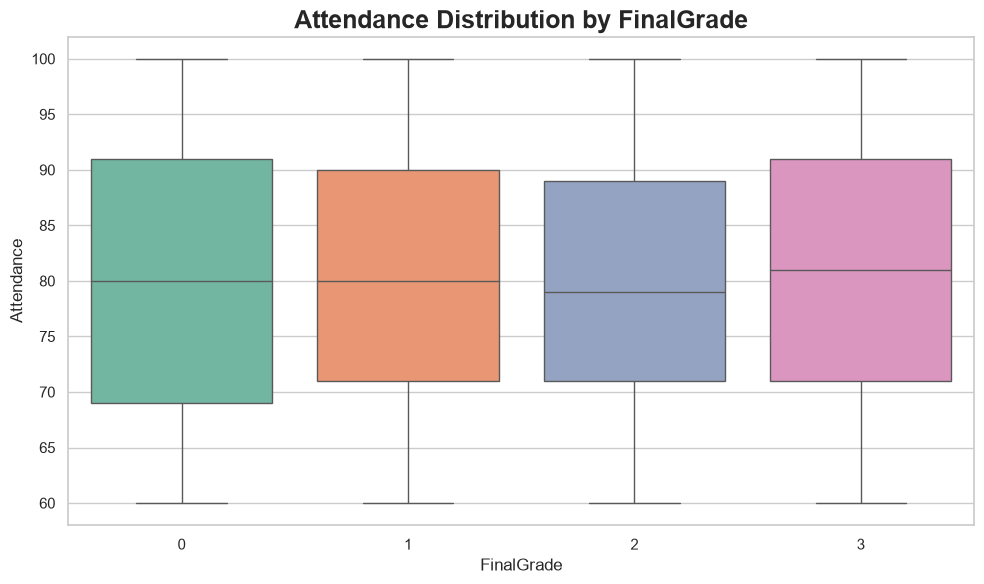

Saved: image\studyhours_distribution_by_finalgrade.png


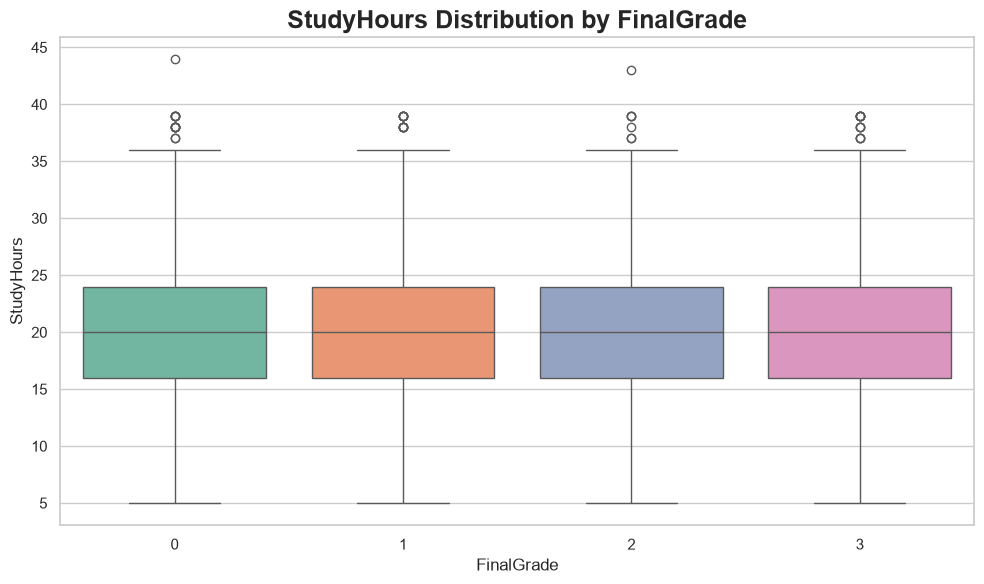

Saved: image\onlinecourses_distribution_by_finalgrade.png


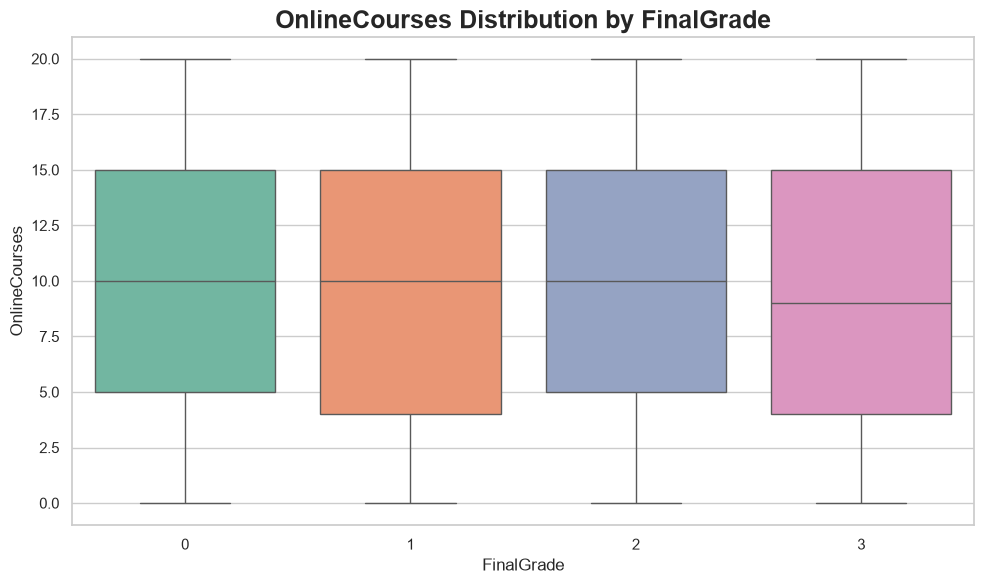

Saved: image\studyhours_normalized_distribution_by_finalgrade.png


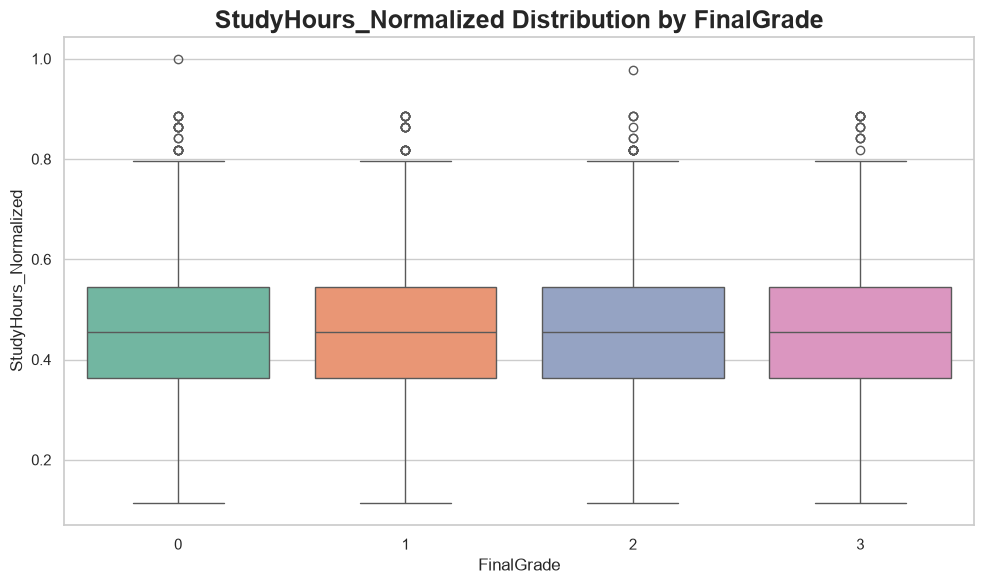

Saved: image\motivation_study_index_distribution_by_finalgrade.png


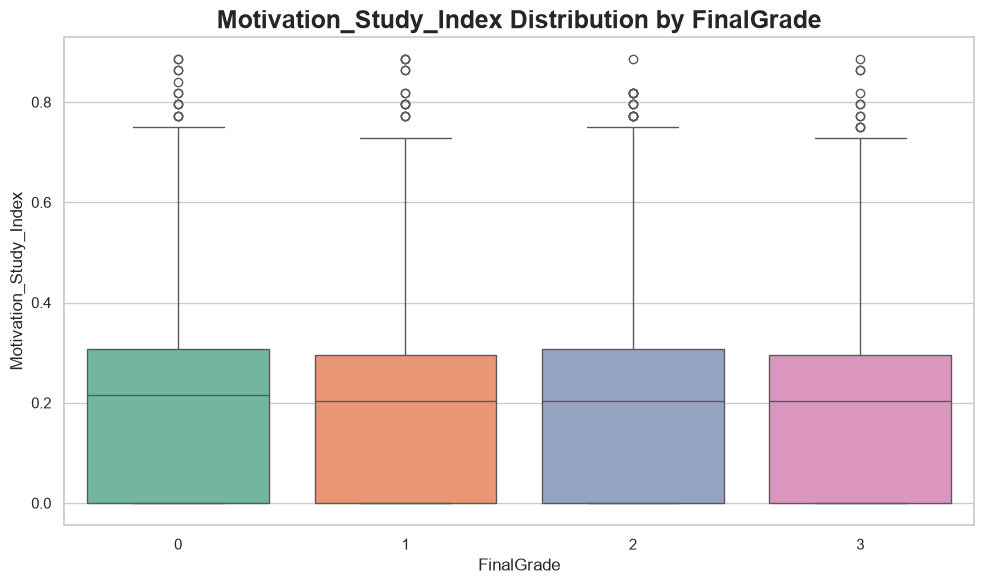

Saved: image\online_learning_activity_distribution_by_finalgrade.png


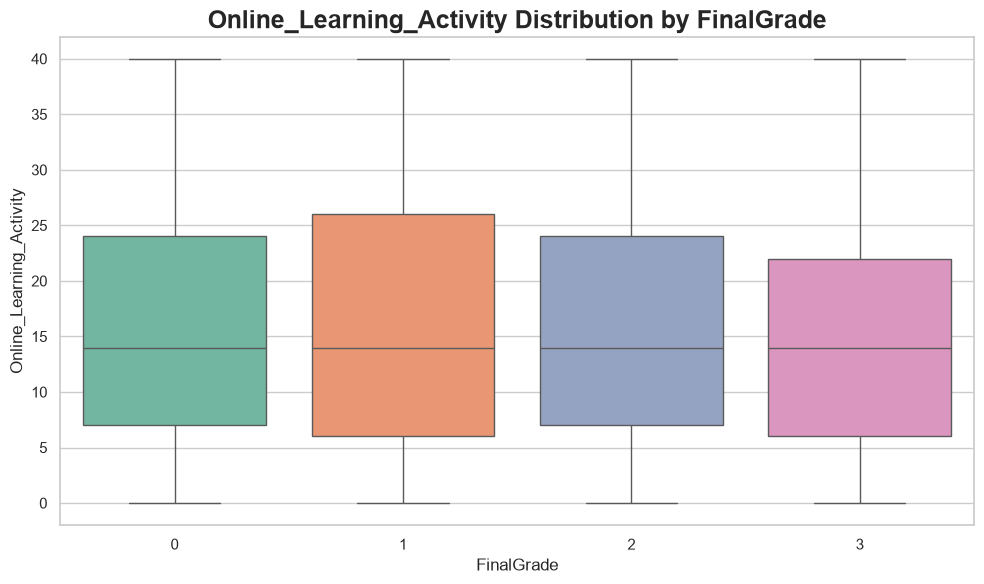

Saved: image\participation_rate_distribution_by_finalgrade.png


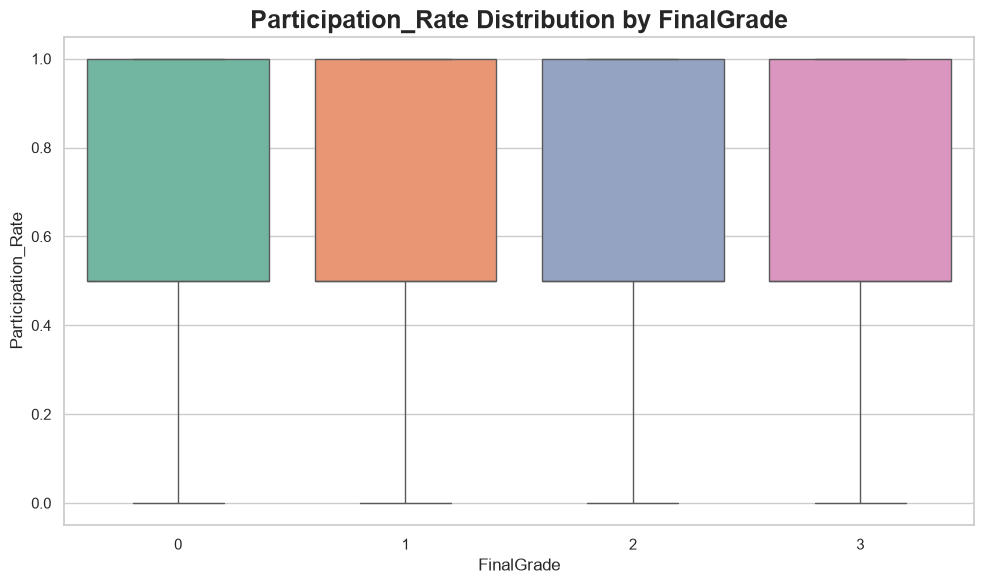

Saved: image\digital_learning_index_distribution_by_finalgrade.png


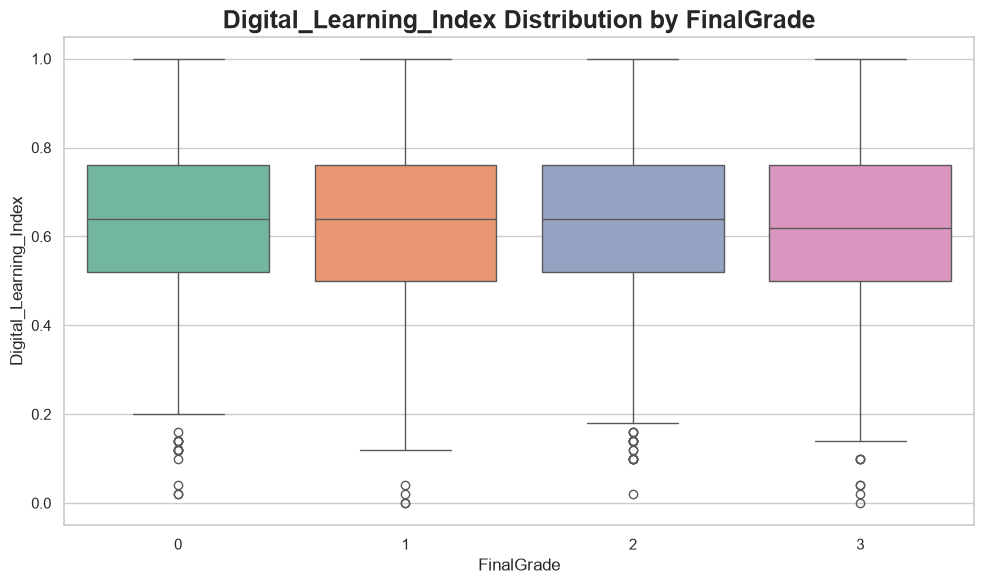

In [29]:
for col in numerical_features:
    title = f"{col} Distribution by FinalGrade"
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x=target, y=col, hue=target, palette="Set2", legend=False)
    plt.xlabel("FinalGrade"); plt.ylabel(col)
    save_plot(title)

Saved: image\learningstyle_distribution_by_finalgrade.png


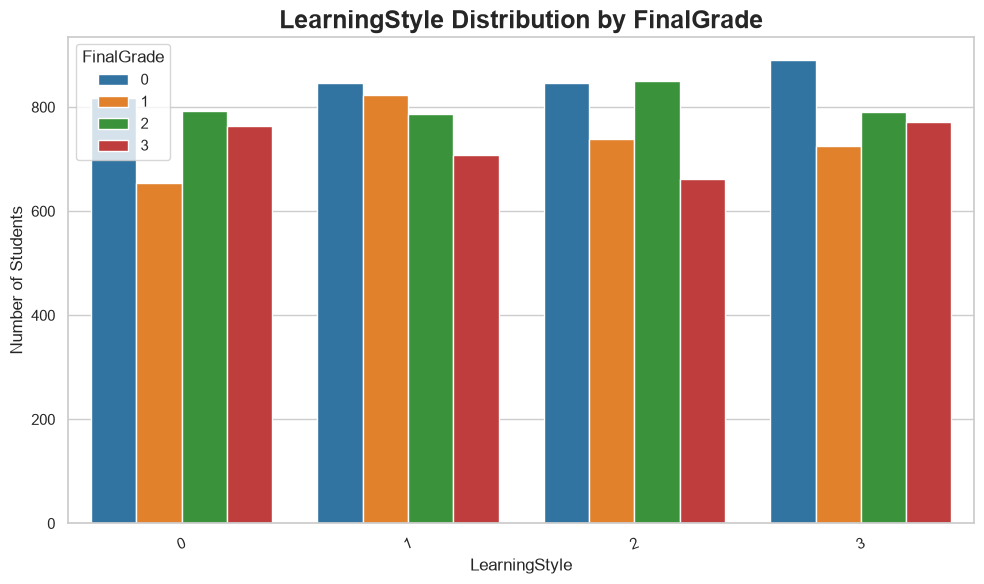

Saved: image\stresslevel_distribution_by_finalgrade.png


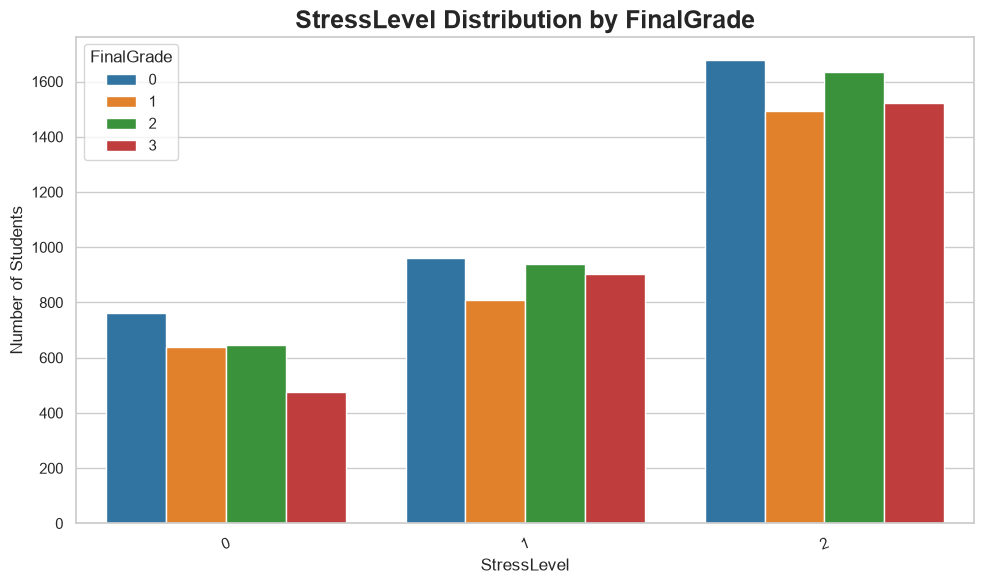

Saved: image\motivation_distribution_by_finalgrade.png


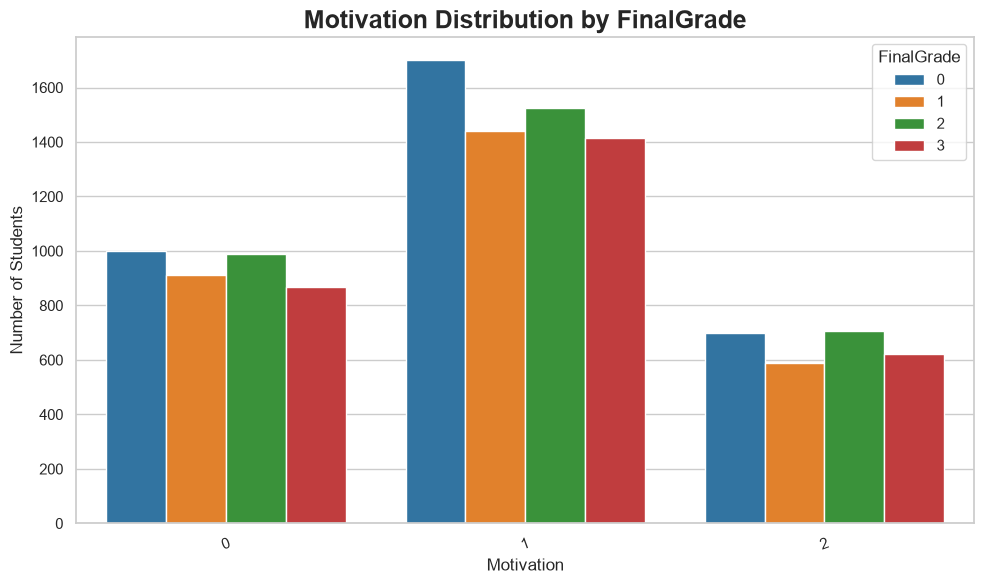

In [30]:
for col in categorical_features:
    title = f"{col} Distribution by FinalGrade"
    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x=col, hue=target, palette="tab10")
    plt.xlabel(col); plt.ylabel("Number of Students"); plt.xticks(rotation=20)
    save_plot(title)

In [31]:
correlation = df[numerical_features + [target]].corr()
display(correlation)

,Academic_Engagement,Assignment_Attendance_Index,Study_Assignment_Index,Study_Attendance_Index,AssignmentCompletion,Attendance_Normalized,Age,Attendance,StudyHours,OnlineCourses,StudyHours_Normalized,Motivation_Study_Index,Online_Learning_Activity,Participation_Rate,Digital_Learning_Index,FinalGrade
Academic_Engagement,1.000000,0.761583,0.636822,0.464482,0.662503,0.390813,-0.037656,0.390813,0.341361,0.010265,0.341361,0.109146,0.009605,0.392499,0.002879,0.003337
Assignment_Attendance_Index,0.761583,1.000000,0.451857,0.260493,0.805103,0.580516,-0.035285,0.580516,0.022566,0.011301,0.022566,0.008982,0.008773,-0.001383,0.000536,-0.019436
Study_Assignment_Index,0.636822,0.451857,1.000000,0.743087,0.545629,0.020650,-0.004391,0.020650,0.826872,0.004948,0.826872,0.288880,0.007909,0.017877,0.008674,-0.024245
Study_Attendance_Index,0.464482,0.260493,0.743087,1.000000,0.005970,0.440675,-0.022102,0.440675,0.900529,0.000226,0.900529,0.310373,0.000307,0.019150,0.003331,-0.003174
AssignmentCompletion,0.662503,0.805103,0.545629,0.005970,1.000000,-0.001892,-0.011710,-0.001892,0.008900,0.011072,0.008900,0.007249,0.013010,-0.003513,0.007058,-0.030413
Attendance_Normalized,0.390813,0.580516,0.020650,0.440675,-0.001892,1.000000,-0.043560,1.000000,0.028129,0.006515,0.028129,0.003830,-0.000388,0.001664,-0.006206,0.011091
Age,-0.037656,-0.035285,-0.004391,-0.022102,-0.011710,-0.043560,1.000000,-0.043560,-0.000619,0.002189,-0.000619,-0.007950,0.000946,-0.017515,0.003875,0.005068
Attendance,0.390813,0.580516,0.020650,0.440675,-0.001892,1.000000,-0.043560,1.000000,0.028129,0.006515,0.028129,0.003830,-0.000388,0.001664,-0.006206,0.011091
StudyHours,0.341361,0.022566,0.826872,0.900529,0.008900,0.028129,-0.000619,0.028129,1.000000,-0.002186,1.000000,0.349069,0.001110,0.022949,0.006640,-0.008999
OnlineCourses,0.010265,0.011301,0.004948,0.000226,0.011072,0.006515,0.002189,0.006515,-0.002186,1.000000,-0.002186,-0.000658,0.844742,-0.000883,0.691445,-0.019453


Saved: image\feature_correlation_heatmap.png


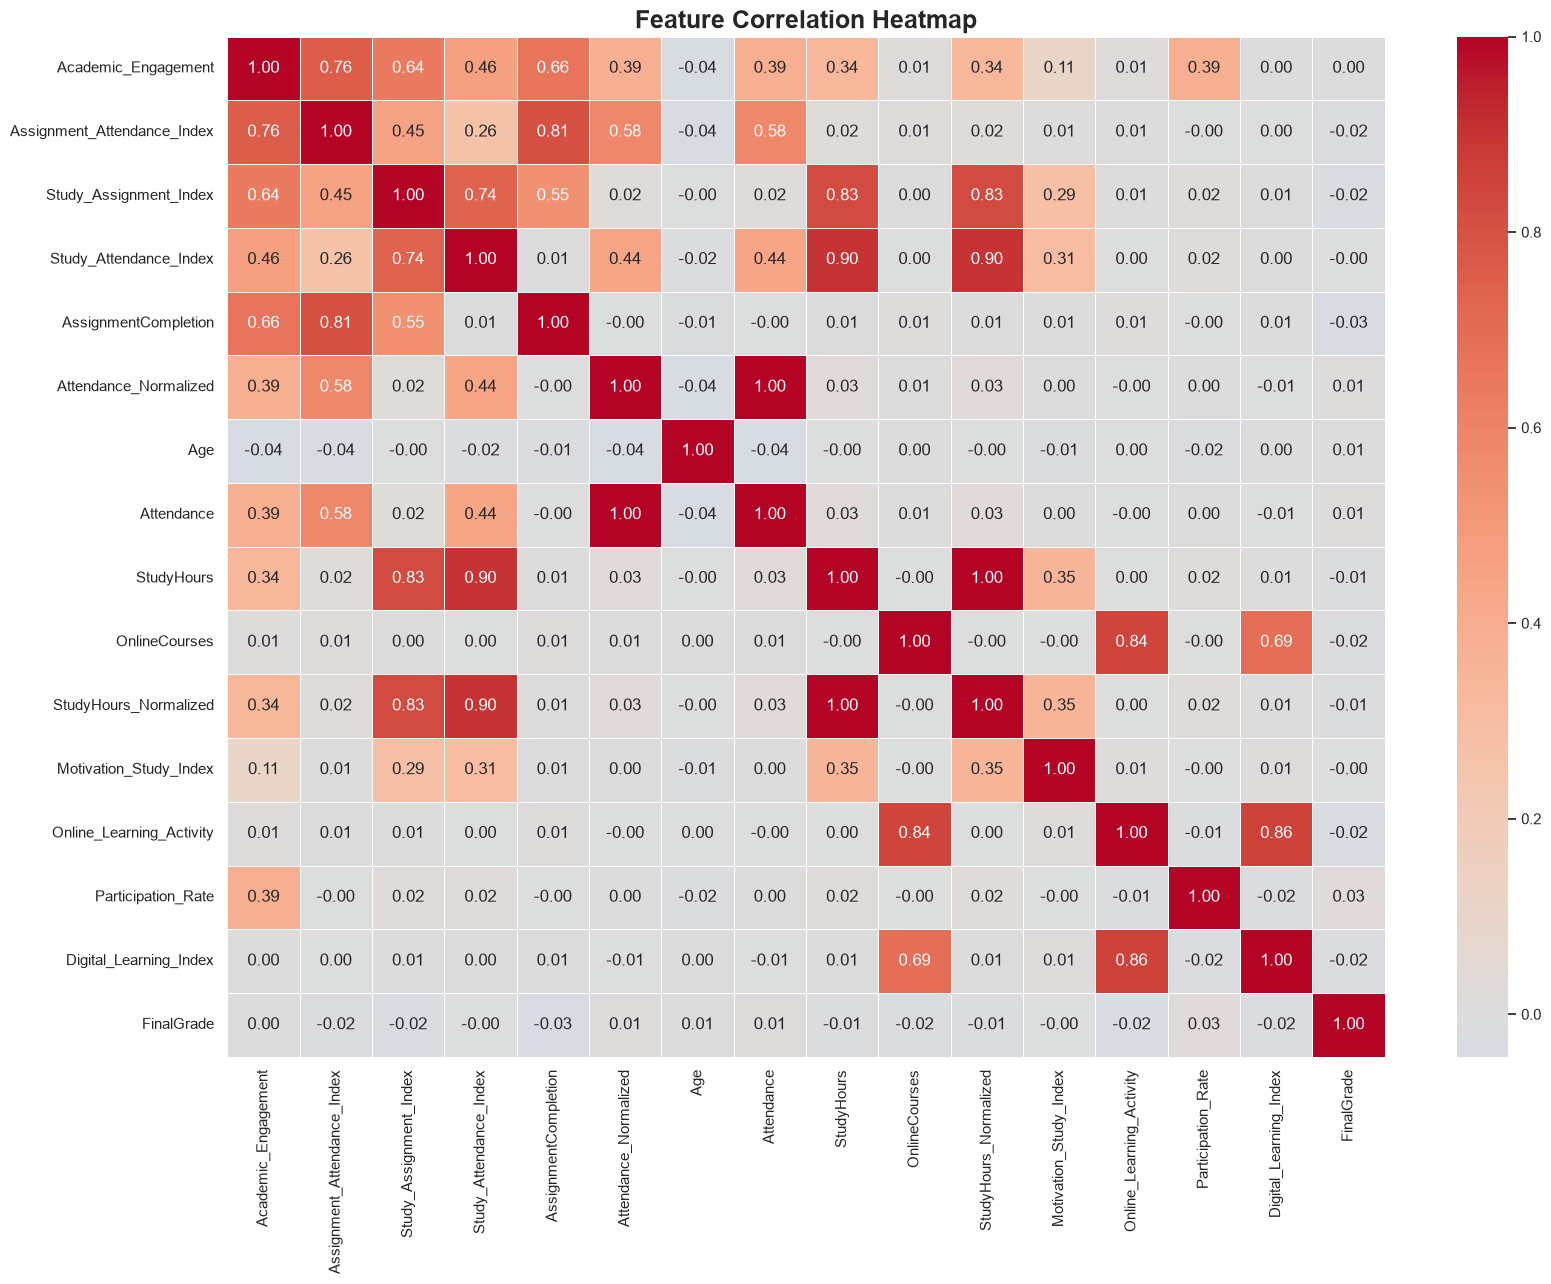

In [32]:
title = "Feature Correlation Heatmap"
plt.figure(figsize=(17,13))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)
save_plot(title)

In [33]:
title = "Interactive Feature Correlation Matrix"
fig = px.imshow(correlation, text_auto=".2f", aspect="auto", color_continuous_scale="RdBu_r", title=title)
fig.update_layout(width=1200, height=900)
save_plotly(fig, title); fig.show()

Saved: image\interactive_feature_correlation_matrix.html


In [34]:
sample_3d = df.sample(min(4000, len(df)), random_state=RANDOM_STATE)
title = "3D Student Performance Visualization"
fig = px.scatter_3d(sample_3d, x="Attendance", y="StudyHours", z="Academic_Engagement", color="FinalGrade", symbol="FinalGrade", opacity=.75, title=title)
fig.update_layout(width=1200, height=850)
save_plotly(fig, title); fig.show()

Saved: image\3d_student_performance_visualization.html


In [35]:
title = "3D Learning Behavior Visualization"
fig = px.scatter_3d(sample_3d, x="Attendance_Normalized", y="Study_Assignment_Index", z="Digital_Learning_Index", color="FinalGrade", size="Academic_Engagement", opacity=.7, title=title)
fig.update_layout(width=1200, height=850)
save_plotly(fig, title); fig.show()

Saved: image\3d_learning_behavior_visualization.html


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_dev, X_val, y_dev, y_val = train_test_split(X_train, y_train, test_size=.20, stratify=y_train, random_state=RANDOM_STATE)
print("Development:", X_dev.shape)
print("Validation:", X_val.shape)
print("Untouched test:", X_test.shape)

Development: (7980, 18)
Validation: (1995, 18)
Untouched test: (2494, 18)


In [37]:
check = pd.DataFrame({"Full": y.value_counts(normalize=True), "Dev": y_dev.value_counts(normalize=True), "Validation": y_val.value_counts(normalize=True), "Test": y_test.value_counts(normalize=True)}).sort_index()
display((check*100).round(2))

,Full,Dev,Validation,Test
FinalGrade,,,,
0,27.28,27.28,27.27,27.27
1,23.60,23.60,23.61,23.62
2,25.83,25.84,25.81,25.82
3,23.29,23.28,23.31,23.30


In [38]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("num", numeric_transformer, numerical_features), ("cat", categorical_transformer, categorical_features)], remainder="drop")
print("Leakage-safe preprocessor created.")

Leakage-safe preprocessor created.


In [39]:
models = {
"01 Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
"02 Ridge Classifier": RidgeClassifier(class_weight="balanced"),
"03 Linear SVM": LinearSVC(C=1, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
"04 SVM RBF": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
"05 SVM Polynomial": SVC(kernel="poly", degree=3, probability=True, class_weight="balanced", random_state=RANDOM_STATE),
"06 Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
"07 Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
"08 Extra Trees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
"09 Gradient Boosting": GradientBoostingClassifier(n_estimators=250, learning_rate=.05, max_depth=3, random_state=RANDOM_STATE),
"10 HistGradientBoosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=.05, max_leaf_nodes=31, random_state=RANDOM_STATE),
"11 AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=.05, random_state=RANDOM_STATE),
"12 Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE),
"13 KNN": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
"14 Gaussian Naive Bayes": GaussianNB(),
"15 Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
"16 Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(reg_param=.1),
"17 MLP Neural Network": MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
"18 LightGBM": LGBMClassifier(objective="multiclass", num_class=4, n_estimators=300, learning_rate=.05, num_leaves=31, max_depth=-1, subsample=.8, colsample_bytree=.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
"19 CatBoost": CatBoostClassifier(loss_function="MultiClass", iterations=300, learning_rate=.05, depth=6, verbose=False, random_seed=RANDOM_STATE, thread_count=-1),
"20 XGBoost": XGBClassifier(objective="multi:softprob", num_class=4, n_estimators=300, learning_rate=.05, max_depth=6, subsample=.8, colsample_bytree=.8, eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
}
print("Total models:", len(models))

Total models: 20


In [40]:
assert len(models) == 20
for i, name in enumerate(models, 1): print(f"{i:02d}. {name[3:]}")

01. Logistic Regression
02. Ridge Classifier
03. Linear SVM
04. SVM RBF
05. SVM Polynomial
06. Decision Tree
07. Random Forest
08. Extra Trees
09. Gradient Boosting
10. HistGradientBoosting
11. AdaBoost
12. Bagging
13. KNN
14. Gaussian Naive Bayes
15. Linear Discriminant Analysis
16. Quadratic Discriminant Analysis
17. MLP Neural Network
18. LightGBM
19. CatBoost
20. XGBoost


In [41]:
pipelines = {name: Pipeline([("preprocessor", preprocessor), ("model", model)]) for name, model in models.items()}
print("Pipelines created:", len(pipelines))

Pipelines created: 20


In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "precision_macro":"precision_macro", "recall_macro":"recall_macro", "f1_macro":"f1_macro", "precision_weighted":"precision_weighted", "recall_weighted":"recall_weighted", "f1_weighted":"f1_weighted"}

In [43]:
validation_results=[]
trained_models={}
for name, pipe in pipelines.items():
    print("Training", name)
    pipe.fit(X_dev, y_dev)
    trained_models[name]=pipe
    p=pipe.predict(X_val)
    validation_results.append({"Model":name,"Accuracy":accuracy_score(y_val,p),"Precision_Macro":precision_score(y_val,p,average="macro",zero_division=0),"Recall_Macro":recall_score(y_val,p,average="macro",zero_division=0),"F1_Macro":f1_score(y_val,p,average="macro",zero_division=0),"Precision_Weighted":precision_score(y_val,p,average="weighted",zero_division=0),"Recall_Weighted":recall_score(y_val,p,average="weighted",zero_division=0),"F1_Weighted":f1_score(y_val,p,average="weighted",zero_division=0)})
model_results_df=pd.DataFrame(validation_results).sort_values("F1_Macro",ascending=False).reset_index(drop=True)
display(model_results_df)

Training 01 Logistic Regression


Training 02 Ridge Classifier
Training 03 Linear SVM
Training 04 SVM RBF
Training 05 SVM Polynomial
Training 06 Decision Tree
Training 07 Random Forest
Training 08 Extra Trees
Training 09 Gradient Boosting
Training 10 HistGradientBoosting
Training 11 AdaBoost
Training 12 Bagging
Training 13 KNN
Training 14 Gaussian Naive Bayes
Training 15 Linear Discriminant Analysis
Training 16 Quadratic Discriminant Analysis
Training 17 MLP Neural Network
Training 18 LightGBM
Training 19 CatBoost
Training 20 XGBoost


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted
0,08 Extra Trees,0.870677,0.871619,0.869719,0.870372,0.871105,0.870677,0.870603
1,12 Bagging,0.863158,0.864907,0.861676,0.862734,0.863941,0.863158,0.863007
2,07 Random Forest,0.859649,0.860418,0.858895,0.859363,0.860113,0.859649,0.859602
3,06 Decision Tree,0.830576,0.832130,0.829246,0.830243,0.831387,0.830576,0.830543
4,10 HistGradientBoosting,0.822055,0.823732,0.820587,0.821586,0.822864,0.822055,0.821900
5,18 LightGBM,0.802506,0.805009,0.800846,0.802156,0.803673,0.802506,0.802332
6,20 XGBoost,0.785464,0.787200,0.783420,0.784597,0.786458,0.785464,0.785263
7,19 CatBoost,0.556391,0.559492,0.551891,0.552429,0.558730,0.556391,0.554335
8,09 Gradient Boosting,0.487218,0.487762,0.482362,0.481971,0.487681,0.487218,0.484372
9,13 KNN,0.455639,0.459546,0.450620,0.449743,0.459052,0.455639,0.451891


In [44]:
display(model_results_df.style.format({"Accuracy":"{:.4f}","Precision_Macro":"{:.4f}","Recall_Macro":"{:.4f}","F1_Macro":"{:.4f}","Precision_Weighted":"{:.4f}","Recall_Weighted":"{:.4f}","F1_Weighted":"{:.4f}"}))

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted
0,08 Extra Trees,0.8707,0.8716,0.8697,0.8704,0.8711,0.8707,0.8706
1,12 Bagging,0.8632,0.8649,0.8617,0.8627,0.8639,0.8632,0.8630
2,07 Random Forest,0.8596,0.8604,0.8589,0.8594,0.8601,0.8596,0.8596
3,06 Decision Tree,0.8306,0.8321,0.8292,0.8302,0.8314,0.8306,0.8305
4,10 HistGradientBoosting,0.8221,0.8237,0.8206,0.8216,0.8229,0.8221,0.8219
5,18 LightGBM,0.8025,0.8050,0.8008,0.8022,0.8037,0.8025,0.8023
6,20 XGBoost,0.7855,0.7872,0.7834,0.7846,0.7865,0.7855,0.7853
7,19 CatBoost,0.5564,0.5595,0.5519,0.5524,0.5587,0.5564,0.5543
8,09 Gradient Boosting,0.4872,0.4878,0.4824,0.4820,0.4877,0.4872,0.4844
9,13 KNN,0.4556,0.4595,0.4506,0.4497,0.4591,0.4556,0.4519


In [45]:
model_results_df.to_csv("artifacts/20_model_validation_comparison.csv", index=False)
print("Saved: artifacts/20_model_validation_comparison.csv")

Saved: artifacts/20_model_validation_comparison.csv


Saved: image\20_model_validation_accuracy_comparison.png


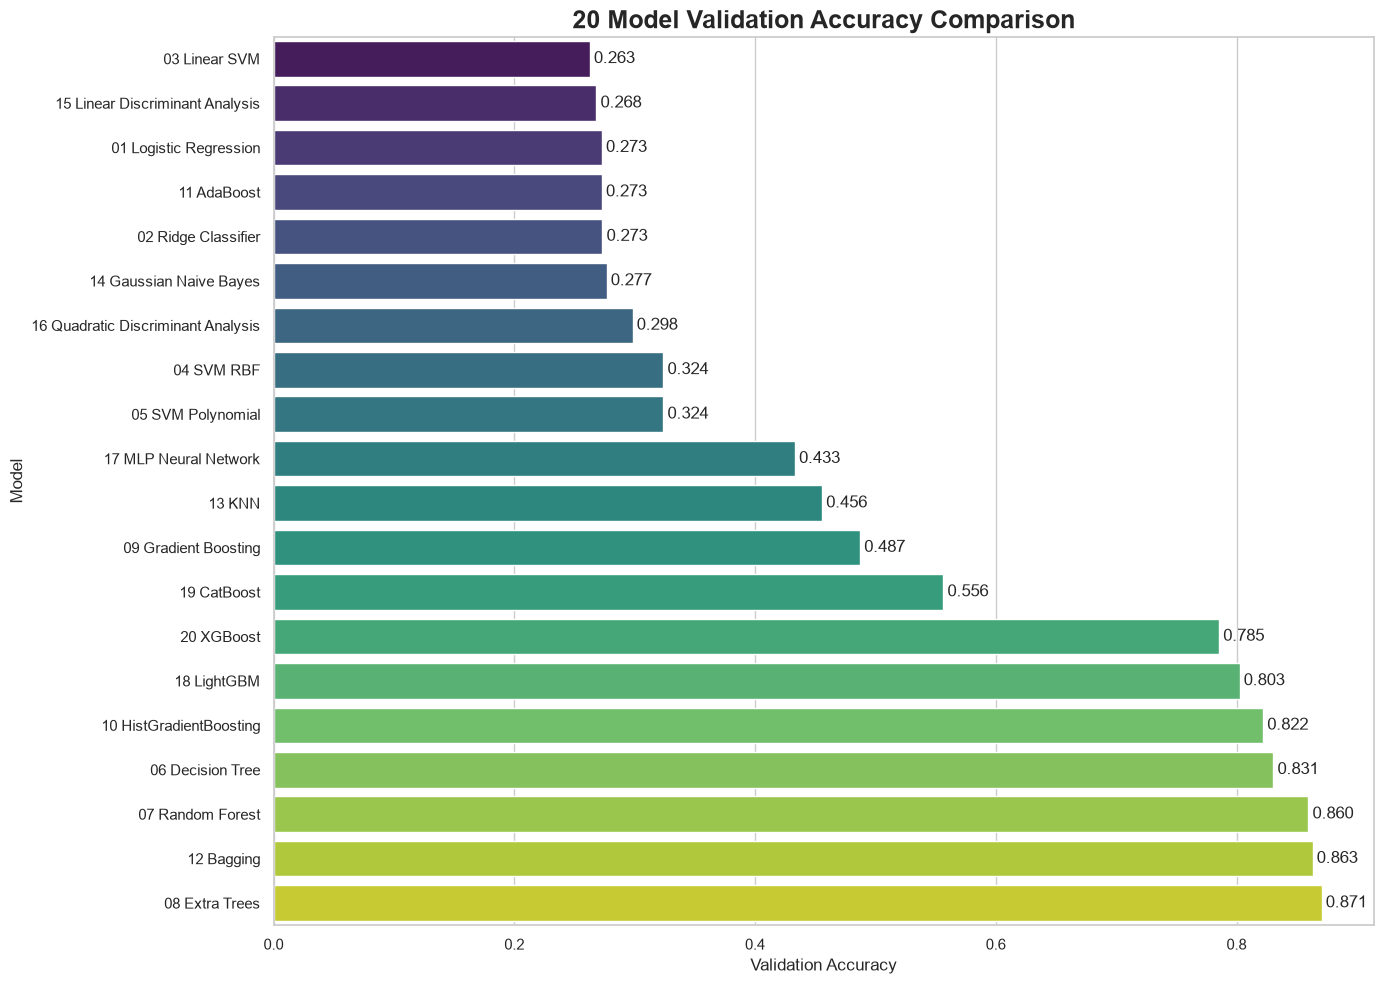

In [46]:
plot_df=model_results_df.sort_values("Accuracy")
title="20 Model Validation Accuracy Comparison"
plt.figure(figsize=(14,10))
ax=sns.barplot(data=plot_df,x="Accuracy",y="Model",hue="Model",palette="viridis",legend=False)
for c in ax.containers: ax.bar_label(c,fmt="%.3f",padding=3)
plt.xlabel("Validation Accuracy"); plt.ylabel("Model")
save_plot(title)

Saved: image\20_model_validation_macro_f1_comparison.png


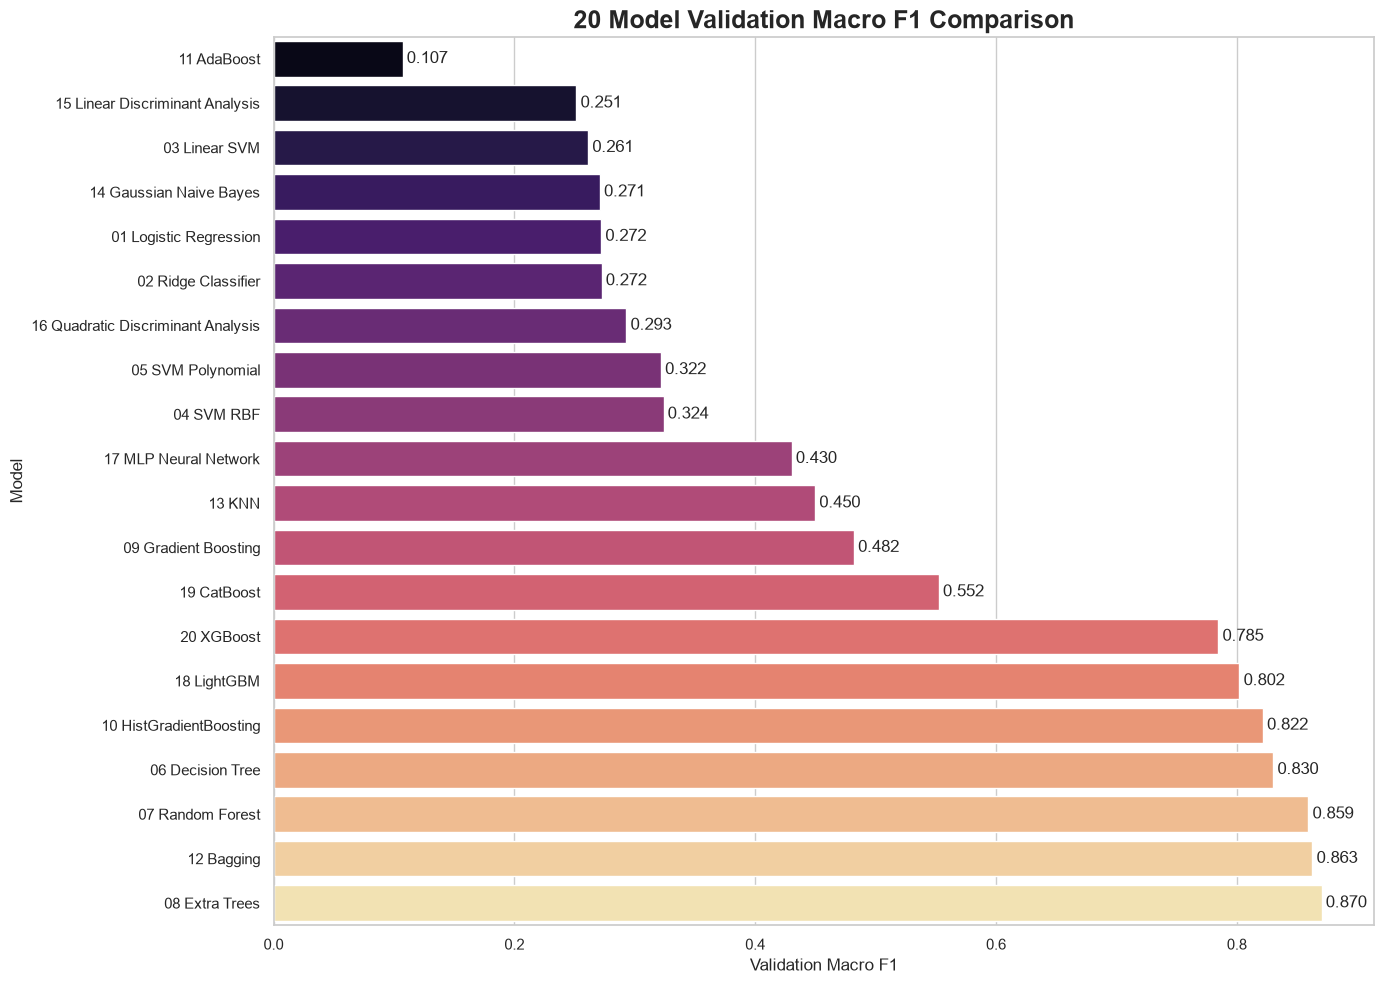

In [47]:
plot_df=model_results_df.sort_values("F1_Macro")
title="20 Model Validation Macro F1 Comparison"
plt.figure(figsize=(14,10))
ax=sns.barplot(data=plot_df,x="F1_Macro",y="Model",hue="Model",palette="magma",legend=False)
for c in ax.containers: ax.bar_label(c,fmt="%.3f",padding=3)
plt.xlabel("Validation Macro F1"); plt.ylabel("Model")
save_plot(title)

Saved: image\top_10_models_precision_recall_f1_comparison.png


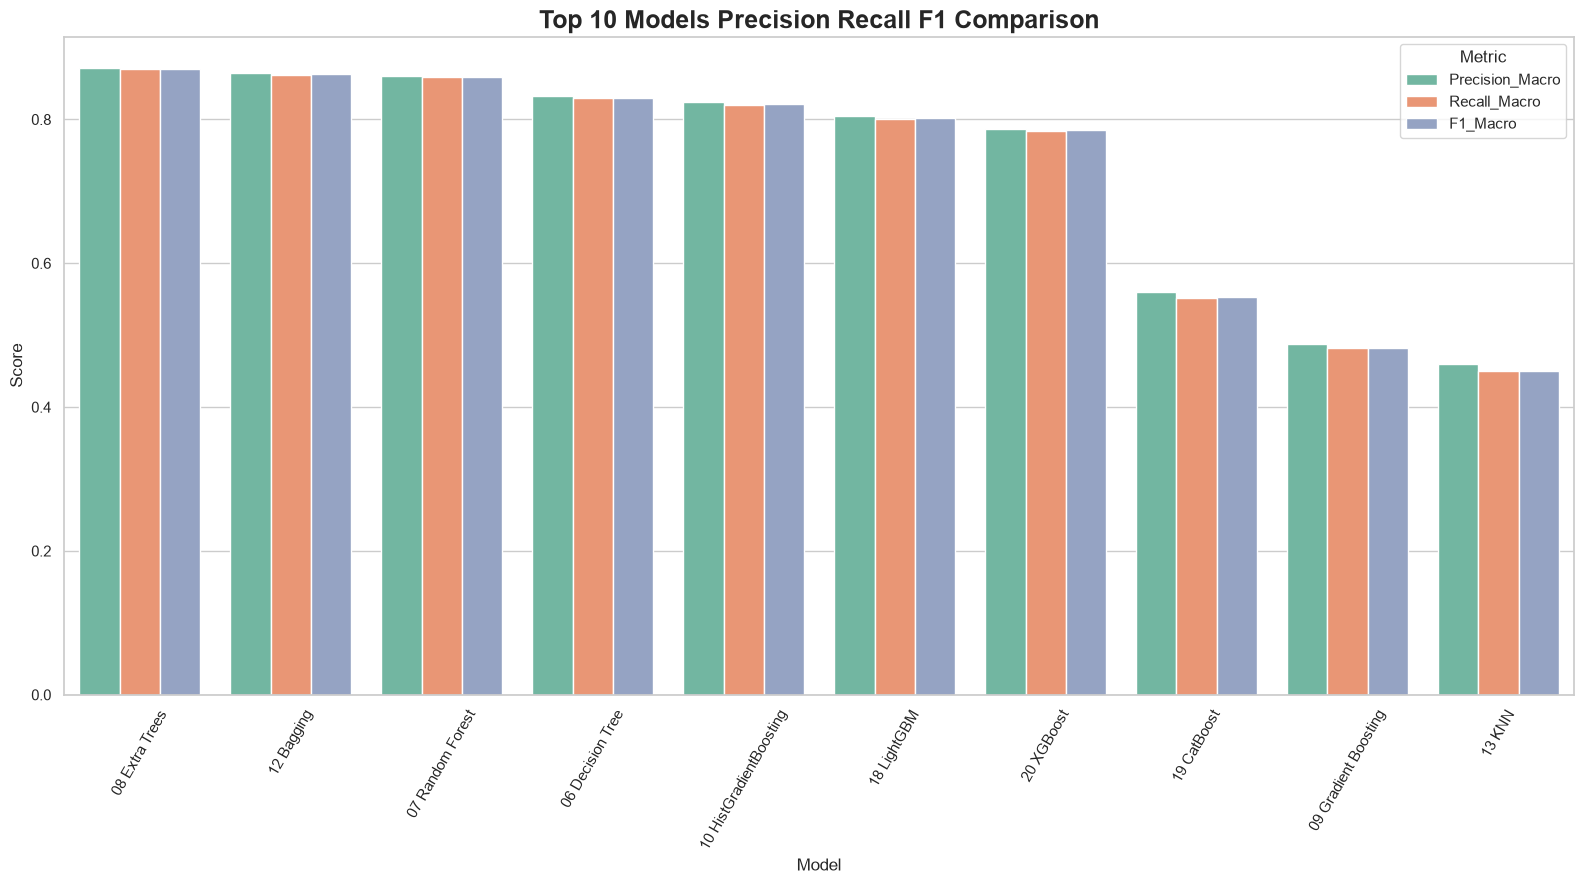

In [48]:
top_plot=model_results_df.head(10).melt(id_vars="Model",value_vars=["Precision_Macro","Recall_Macro","F1_Macro"],var_name="Metric",value_name="Score")
title="Top 10 Models Precision Recall F1 Comparison"
plt.figure(figsize=(16,9))
sns.barplot(data=top_plot,x="Model",y="Score",hue="Metric",palette="Set2")
plt.xticks(rotation=60)
save_plot(title)

In [49]:
title="Interactive 20 Model Validation Performance Comparison"
fig=px.bar(model_results_df,x="Model",y=["Accuracy","Precision_Macro","Recall_Macro","F1_Macro"],barmode="group",title=title)
fig.update_layout(width=1500,height=850,xaxis_tickangle=-55)
save_plotly(fig,title); fig.show()

Saved: image\interactive_20_model_validation_performance_comparison.html


In [50]:
cv_results=[]
for name, pipe in pipelines.items():
    print("Cross-validating", name)
    s=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1,return_train_score=False)
    cv_results.append({"Model":name,"Accuracy_Mean":s["test_accuracy"].mean(),"Accuracy_STD":s["test_accuracy"].std(),"F1_Macro_Mean":s["test_f1_macro"].mean(),"F1_Macro_STD":s["test_f1_macro"].std(),"F1_Weighted_Mean":s["test_f1_weighted"].mean(),"F1_Weighted_STD":s["test_f1_weighted"].std(),"Precision_Macro_Mean":s["test_precision_macro"].mean(),"Recall_Macro_Mean":s["test_recall_macro"].mean()})
cv_results_df=pd.DataFrame(cv_results).sort_values("F1_Macro_Mean",ascending=False).reset_index(drop=True)
display(cv_results_df)

Cross-validating 01 Logistic Regression
Cross-validating 02 Ridge Classifier
Cross-validating 03 Linear SVM
Cross-validating 04 SVM RBF
Cross-validating 05 SVM Polynomial
Cross-validating 06 Decision Tree
Cross-validating 07 Random Forest
Cross-validating 08 Extra Trees
Cross-validating 09 Gradient Boosting
Cross-validating 10 HistGradientBoosting
Cross-validating 11 AdaBoost
Cross-validating 12 Bagging
Cross-validating 13 KNN
Cross-validating 14 Gaussian Naive Bayes
Cross-validating 15 Linear Discriminant Analysis
Cross-validating 16 Quadratic Discriminant Analysis
Cross-validating 17 MLP Neural Network
Cross-validating 18 LightGBM
Cross-validating 19 CatBoost
Cross-validating 20 XGBoost


,Model,Accuracy_Mean,Accuracy_STD,F1_Macro_Mean,F1_Macro_STD,F1_Weighted_Mean,F1_Weighted_STD,Precision_Macro_Mean,Recall_Macro_Mean
0,12 Bagging,0.862456,0.006103,0.862336,0.006241,0.862416,0.006107,0.863496,0.861725
1,08 Extra Trees,0.861955,0.007212,0.861898,0.007247,0.861918,0.007200,0.862741,0.861529
2,07 Random Forest,0.861855,0.005747,0.861614,0.005698,0.861821,0.005742,0.862133,0.861337
3,06 Decision Tree,0.813835,0.014349,0.813553,0.014515,0.813880,0.014343,0.813427,0.813895
4,10 HistGradientBoosting,0.809223,0.006193,0.808973,0.005780,0.809164,0.006132,0.810783,0.808070
5,18 LightGBM,0.803108,0.008862,0.802863,0.008812,0.803035,0.008835,0.804863,0.801868
6,20 XGBoost,0.779749,0.009973,0.779445,0.009622,0.779659,0.009860,0.782197,0.778209
7,19 CatBoost,0.568421,0.017436,0.564819,0.016243,0.566375,0.016572,0.576397,0.563649
8,17 MLP Neural Network,0.502556,0.024381,0.500111,0.024608,0.501653,0.024475,0.502057,0.500164
9,09 Gradient Boosting,0.490526,0.010870,0.485108,0.010200,0.487260,0.010152,0.495742,0.485347


In [51]:
display(cv_results_df.style.format({"Accuracy_Mean":"{:.4f}","Accuracy_STD":"{:.4f}","F1_Macro_Mean":"{:.4f}","F1_Macro_STD":"{:.4f}","F1_Weighted_Mean":"{:.4f}","F1_Weighted_STD":"{:.4f}","Precision_Macro_Mean":"{:.4f}","Recall_Macro_Mean":"{:.4f}"}))

,Model,Accuracy_Mean,Accuracy_STD,F1_Macro_Mean,F1_Macro_STD,F1_Weighted_Mean,F1_Weighted_STD,Precision_Macro_Mean,Recall_Macro_Mean
0,12 Bagging,0.8625,0.0061,0.8623,0.0062,0.8624,0.0061,0.8635,0.8617
1,08 Extra Trees,0.8620,0.0072,0.8619,0.0072,0.8619,0.0072,0.8627,0.8615
2,07 Random Forest,0.8619,0.0057,0.8616,0.0057,0.8618,0.0057,0.8621,0.8613
3,06 Decision Tree,0.8138,0.0143,0.8136,0.0145,0.8139,0.0143,0.8134,0.8139
4,10 HistGradientBoosting,0.8092,0.0062,0.8090,0.0058,0.8092,0.0061,0.8108,0.8081
5,18 LightGBM,0.8031,0.0089,0.8029,0.0088,0.8030,0.0088,0.8049,0.8019
6,20 XGBoost,0.7797,0.0100,0.7794,0.0096,0.7797,0.0099,0.7822,0.7782
7,19 CatBoost,0.5684,0.0174,0.5648,0.0162,0.5664,0.0166,0.5764,0.5636
8,17 MLP Neural Network,0.5026,0.0244,0.5001,0.0246,0.5017,0.0245,0.5021,0.5002
9,09 Gradient Boosting,0.4905,0.0109,0.4851,0.0102,0.4873,0.0102,0.4957,0.4853


In [52]:
cv_results_df.to_csv("artifacts/20_model_cross_validation.csv",index=False)
print("Saved: artifacts/20_model_cross_validation.csv")

Saved: artifacts/20_model_cross_validation.csv


Saved: image\20_model_5_fold_cross_validation_macro_f1.png


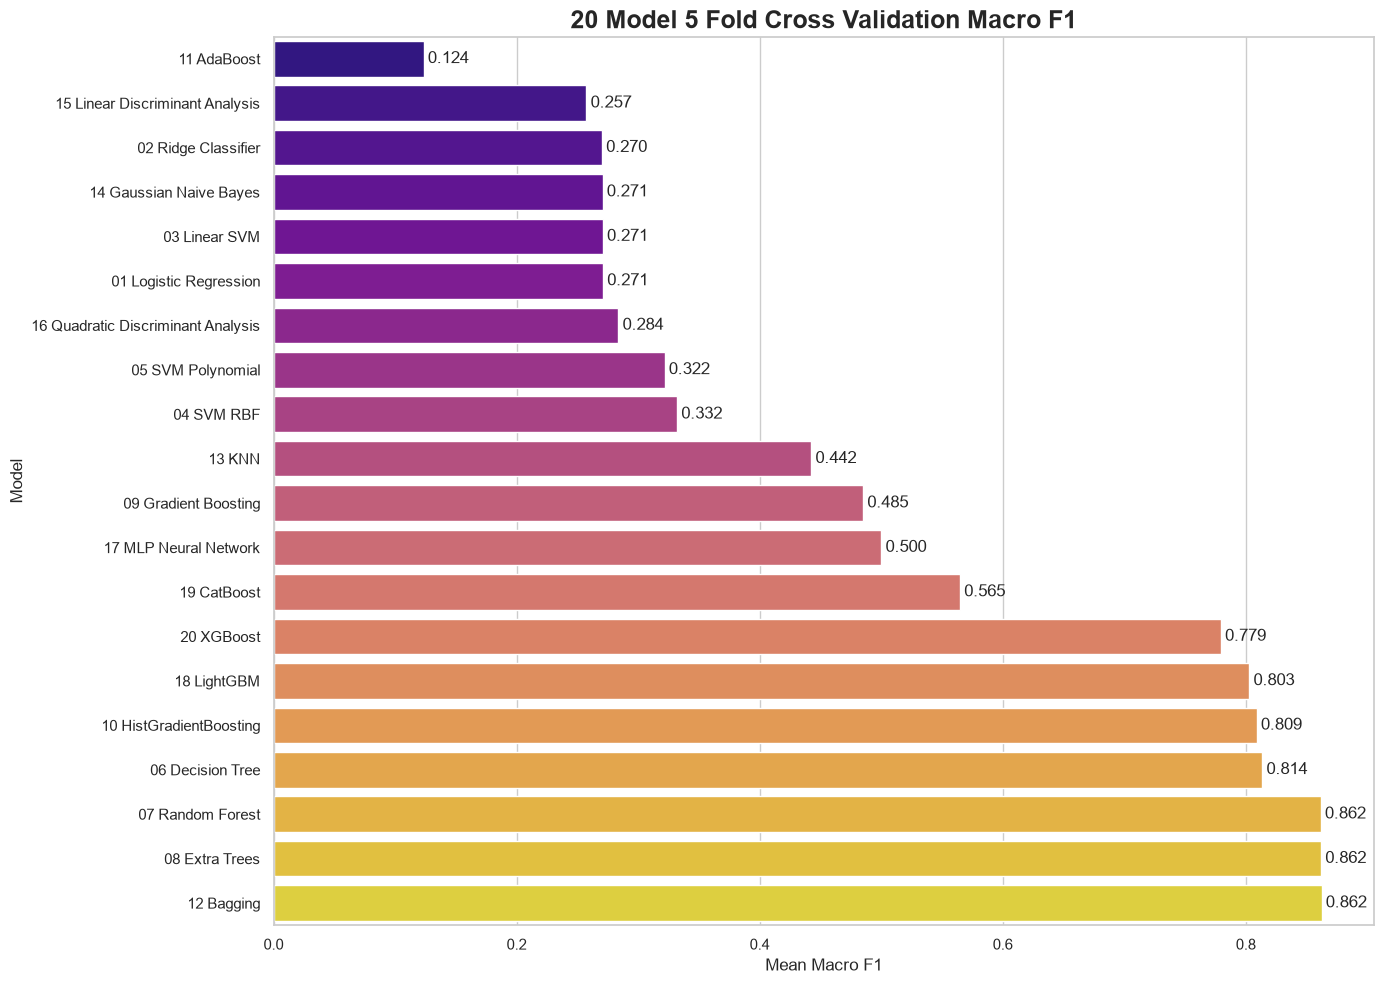

In [53]:
plot_df=cv_results_df.sort_values("F1_Macro_Mean")
title="20 Model 5 Fold Cross Validation Macro F1"
plt.figure(figsize=(14,10))
ax=sns.barplot(data=plot_df,x="F1_Macro_Mean",y="Model",hue="Model",palette="plasma",legend=False)
for c in ax.containers: ax.bar_label(c,fmt="%.3f",padding=3)
plt.xlabel("Mean Macro F1"); plt.ylabel("Model")
save_plot(title)

In [54]:
top_5_models=cv_results_df.head(5)["Model"].tolist()
for i,name in enumerate(top_5_models,1): print(f"{i}. {name}")

1. 12 Bagging
2. 08 Extra Trees
3. 07 Random Forest
4. 06 Decision Tree
5. 10 HistGradientBoosting


In [55]:
param_grids={
"01 Logistic Regression":{"model__C":[.01,.1,1,10],"model__class_weight":[None,"balanced"]},
"02 Ridge Classifier":{"model__alpha":[.1,1,10,100],"model__class_weight":[None,"balanced"]},
"03 Linear SVM":{"model__C":[.01,.1,1,10],"model__class_weight":[None,"balanced"]},
"04 SVM RBF":{"model__C":[.1,1,10],"model__gamma":["scale","auto"]},
"05 SVM Polynomial":{"model__C":[.1,1,10],"model__degree":[2,3],"model__gamma":["scale","auto"]},
"06 Decision Tree":{"model__max_depth":[None,5,10,20],"model__min_samples_split":[2,5,10],"model__min_samples_leaf":[1,2,5]},
"07 Random Forest":{"model__n_estimators":[200,400],"model__max_depth":[None,10,20],"model__min_samples_split":[2,5],"model__min_samples_leaf":[1,2],"model__max_features":["sqrt","log2"]},
"08 Extra Trees":{"model__n_estimators":[200,400],"model__max_depth":[None,10,20],"model__min_samples_split":[2,5],"model__min_samples_leaf":[1,2],"model__max_features":["sqrt","log2"]},
"09 Gradient Boosting":{"model__n_estimators":[100,200],"model__learning_rate":[.03,.05,.1],"model__max_depth":[2,3,5]},
"10 HistGradientBoosting":{"model__max_iter":[100,200,300],"model__learning_rate":[.03,.05,.1],"model__max_leaf_nodes":[15,31,63]},
"11 AdaBoost":{"model__n_estimators":[100,200],"model__learning_rate":[.03,.05,.1]},
"12 Bagging":{"model__n_estimators":[100,200],"model__max_samples":[.7,1.0],"model__max_features":[.7,1.0]},
"13 KNN":{"model__n_neighbors":[3,5,7,9,11],"model__weights":["uniform","distance"],"model__p":[1,2]},
"14 Gaussian Naive Bayes":{"model__var_smoothing":[1e-11,1e-9,1e-7,1e-5]},
"15 Linear Discriminant Analysis":{"model__solver":["svd","lsqr"]},
"16 Quadratic Discriminant Analysis":{"model__reg_param":[0,.1,.3,.5]},
"17 MLP Neural Network":{"model__hidden_layer_sizes":[(64,32),(128,64),(128,64,32)],"model__alpha":[.0001,.001,.01],"model__learning_rate_init":[.001,.005]},
"18 LightGBM":{"model__n_estimators":[200,400],"model__learning_rate":[.03,.05,.1],"model__num_leaves":[15,31,63],"model__max_depth":[-1,5,10]},
"19 CatBoost":{"model__iterations":[200,400],"model__learning_rate":[.03,.05,.1],"model__depth":[4,6,8],"model__l2_leaf_reg":[1,3,5]},
"20 XGBoost":{"model__n_estimators":[200,400],"model__learning_rate":[.03,.05,.1],"model__max_depth":[3,5,7],"model__subsample":[.8,1.0],"model__colsample_bytree":[.8,1.0]}
}
print("Parameter grids prepared for all 20 models.")

Parameter grids prepared for all 20 models.


In [56]:
top_3_models=cv_results_df.head(3)["Model"].tolist()
grid_searches={}; grid_summary=[]
for name in top_3_models:
    print("\nGRID SEARCH:",name)
    grid=GridSearchCV(pipelines[name],param_grids[name],scoring="f1_macro",cv=cv,n_jobs=-1,verbose=1,refit=True)
    grid.fit(X_train,y_train)
    grid_searches[name]=grid
    grid_summary.append({"Model":name,"Best_CV_Macro_F1":grid.best_score_,"Best_Parameters":grid.best_params_})
grid_summary_df=pd.DataFrame(grid_summary).sort_values("Best_CV_Macro_F1",ascending=False)
display(grid_summary_df)


GRID SEARCH: 12 Bagging
Fitting 5 folds for each of 8 candidates, totalling 40 fits

GRID SEARCH: 08 Extra Trees
Fitting 5 folds for each of 48 candidates, totalling 240 fits

GRID SEARCH: 07 Random Forest
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,Model,Best_CV_Macro_F1,Best_Parameters
0,12 Bagging,0.863936,"{'model__max_features': 1.0, 'model__max_sampl..."
1,08 Extra Trees,0.862904,"{'model__max_depth': None, 'model__max_feature..."
2,07 Random Forest,0.862565,"{'model__max_depth': None, 'model__max_feature..."


In [57]:
best_tuned_name=grid_summary_df.iloc[0]["Model"]
best_grid=grid_searches[best_tuned_name]
best_tuned_cv_score=best_grid.best_score_
print("Best tuned model:",best_tuned_name)
print("Best CV Macro F1:",round(best_tuned_cv_score,4))
print("Best parameters:",best_grid.best_params_)

Best tuned model: 12 Bagging
Best CV Macro F1: 0.8639
Best parameters: {'model__max_features': 1.0, 'model__max_samples': 1.0, 'model__n_estimators': 100}


In [58]:
grid_summary_df.to_csv("artifacts/gridsearch_results.csv",index=False)
print("Saved: artifacts/gridsearch_results.csv")

Saved: artifacts/gridsearch_results.csv


In [59]:
final_model=best_grid.best_estimator_
print("Final selected model:",best_tuned_name)
print("Test set remains untouched until this point.")

Final selected model: 12 Bagging
Test set remains untouched until this point.


In [60]:
final_test_predictions=final_model.predict(X_test)
print("Final test predictions generated.")

Final test predictions generated.


In [61]:
final_metrics={
"Accuracy":accuracy_score(y_test,final_test_predictions),
"Precision Macro":precision_score(y_test,final_test_predictions,average="macro",zero_division=0),
"Recall Macro":recall_score(y_test,final_test_predictions,average="macro",zero_division=0),
"F1 Macro":f1_score(y_test,final_test_predictions,average="macro",zero_division=0),
"Precision Weighted":precision_score(y_test,final_test_predictions,average="weighted",zero_division=0),
"Recall Weighted":recall_score(y_test,final_test_predictions,average="weighted",zero_division=0),
"F1 Weighted":f1_score(y_test,final_test_predictions,average="weighted",zero_division=0)}
final_metrics_df=pd.DataFrame([final_metrics])
display(final_metrics_df.style.format("{:.4f}"))

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0,0.9118,0.9126,0.9112,0.9118,0.9120,0.9118,0.9118


In [62]:
print(classification_report(y_test,final_test_predictions,digits=4,zero_division=0))

              precision    recall  f1-score   support

           0     0.9033    0.9206    0.9119       680
           1     0.9077    0.9015    0.9046       589
           2     0.9052    0.9193    0.9122       644
           3     0.9342    0.9036    0.9186       581

    accuracy                         0.9118      2494
   macro avg     0.9126    0.9112    0.9118      2494
weighted avg     0.9120    0.9118    0.9118      2494



In [63]:
report_dict=classification_report(y_test,final_test_predictions,output_dict=True,zero_division=0)
per_class_df=pd.DataFrame(report_dict).T
display(per_class_df.style.format("{:.4f}"))

,precision,recall,f1-score,support
0,0.9033,0.9206,0.9119,680.0000
1,0.9077,0.9015,0.9046,589.0000
2,0.9052,0.9193,0.9122,644.0000
3,0.9342,0.9036,0.9186,581.0000
accuracy,0.9118,0.9118,0.9118,0.9118
macro avg,0.9126,0.9112,0.9118,2494.0000
weighted avg,0.9120,0.9118,0.9118,2494.0000


Saved: image/confusion_matrix_-_12_bagging.png


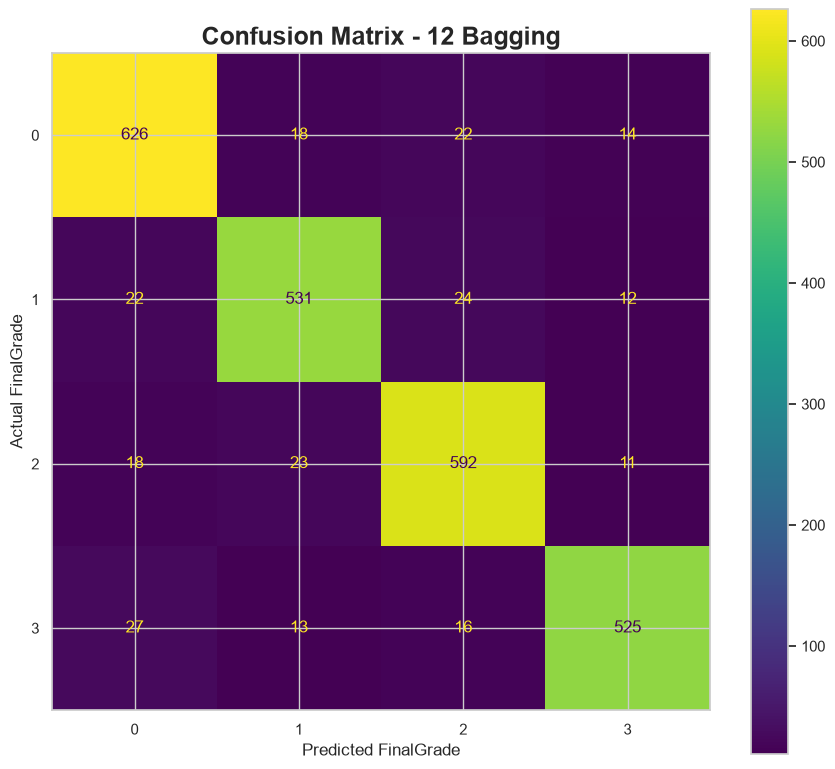

In [64]:
cm=confusion_matrix(y_test,final_test_predictions)
title=f"Confusion Matrix - {best_tuned_name}"
fig,ax=plt.subplots(figsize=(9,8))
ConfusionMatrixDisplay(cm,display_labels=sorted(y.unique())).plot(ax=ax,cmap="viridis",colorbar=True)
ax.set_title(title,fontsize=18,fontweight="bold"); ax.set_xlabel("Predicted FinalGrade"); ax.set_ylabel("Actual FinalGrade")
plt.tight_layout(); path=f"image/{clean_filename(title)}.png"; plt.savefig(path,dpi=300,bbox_inches="tight"); print("Saved:",path); plt.show(); plt.close()

Saved: image\normalized_confusion_matrix_-_12_bagging.png


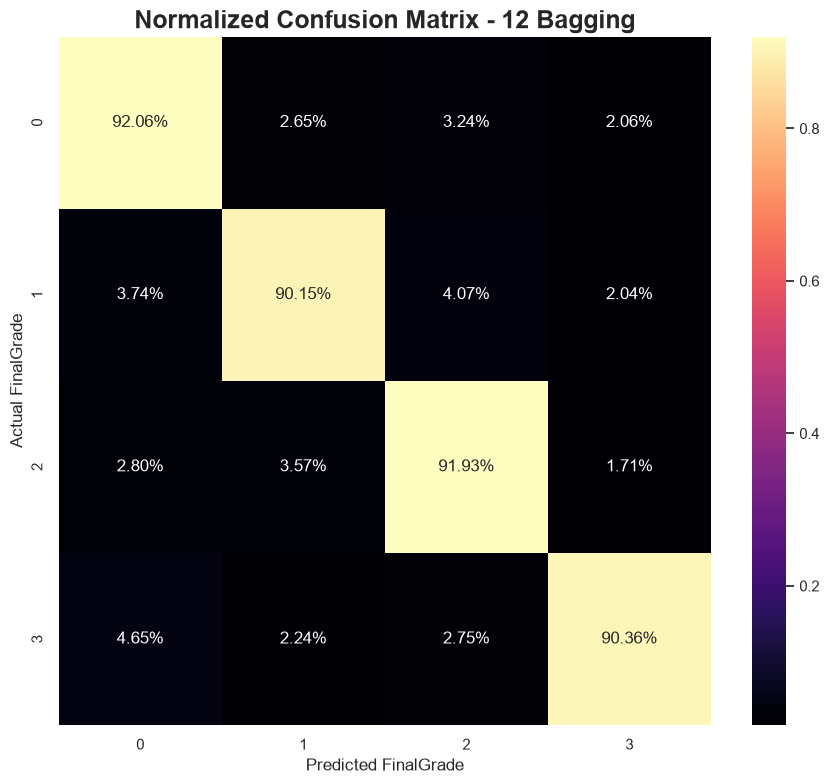

In [65]:
cm_normalized=confusion_matrix(y_test,final_test_predictions,normalize="true")
title=f"Normalized Confusion Matrix - {best_tuned_name}"
plt.figure(figsize=(9,8)); sns.heatmap(cm_normalized,annot=True,fmt=".2%",cmap="magma",xticklabels=sorted(y.unique()),yticklabels=sorted(y.unique()))
plt.xlabel("Predicted FinalGrade"); plt.ylabel("Actual FinalGrade")
save_plot(title)

In [66]:
title=f"Interactive Confusion Matrix - {best_tuned_name}"
fig=go.Figure(go.Heatmap(z=cm,x=[f"Class {x}" for x in sorted(y.unique())],y=[f"Class {x}" for x in sorted(y.unique())],text=cm,texttemplate="%{text}",colorscale="Viridis"))
fig.update_layout(title=title,xaxis_title="Predicted FinalGrade",yaxis_title="Actual FinalGrade",width=900,height=800)
save_plotly(fig,title); fig.show()

Saved: image\interactive_confusion_matrix_-_12_bagging.html


Saved: image\final_model_performance_-_12_bagging.png


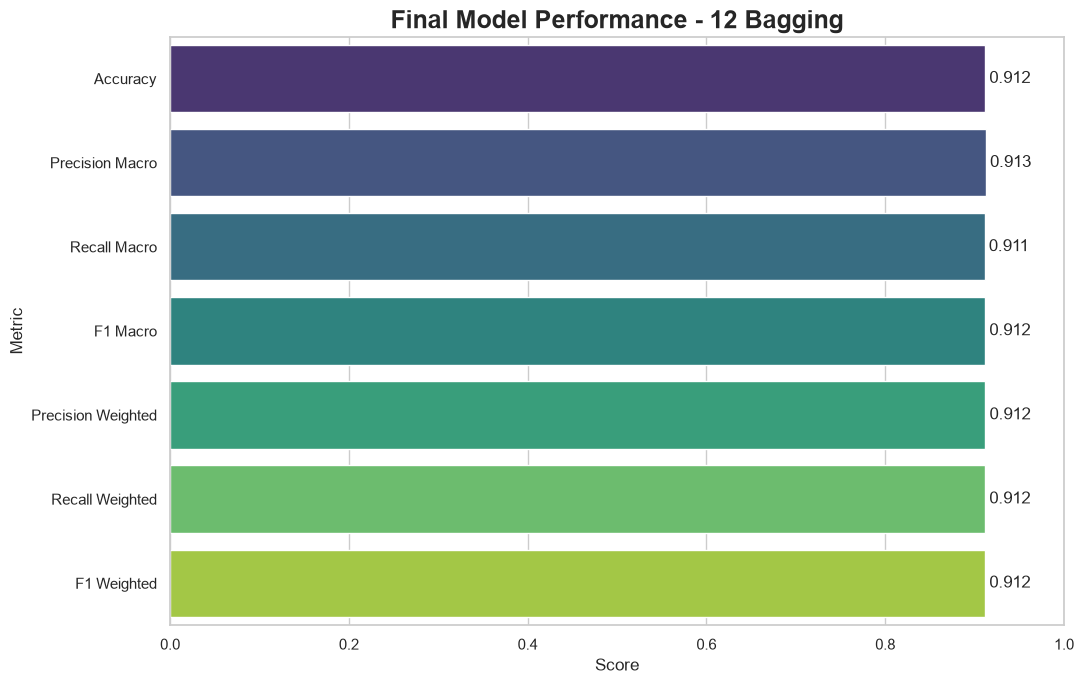

In [67]:
s=pd.Series(final_metrics)
title=f"Final Model Performance - {best_tuned_name}"
plt.figure(figsize=(11,7)); ax=sns.barplot(x=s.values,y=s.index,hue=s.index,palette="viridis",legend=False)
for c in ax.containers: ax.bar_label(c,fmt="%.3f",padding=3)
plt.xlim(0,1); plt.xlabel("Score"); plt.ylabel("Metric")
save_plot(title)

In [68]:
fitted_preprocessor=final_model.named_steps["preprocessor"]
transformed_feature_names=fitted_preprocessor.get_feature_names_out()
print("Total transformed features:",len(transformed_feature_names))

Total transformed features: 25


In [69]:
final_estimator=final_model.named_steps["model"]
if hasattr(final_estimator,"feature_importances_"):
    native_importance=final_estimator.feature_importances_
    feature_importance_df=pd.DataFrame({"Feature":transformed_feature_names,"Importance":native_importance}).sort_values("Importance",ascending=False).reset_index(drop=True)
    display(feature_importance_df.head(30))
else:
    feature_importance_df=None
    print("Native feature importance is not available for this model.")

Native feature importance is not available for this model.


In [70]:
if feature_importance_df is not None:
    top_features=feature_importance_df.head(20).sort_values("Importance")
    title=f"Top 20 Feature Importance - {best_tuned_name}"
    plt.figure(figsize=(13,9)); sns.barplot(data=top_features,x="Importance",y="Feature",hue="Feature",palette="rocket",legend=False)
    plt.xlabel("Importance"); plt.ylabel("Feature")
    save_plot(title)

In [71]:
permutation=permutation_importance(final_model,X_test,y_test,scoring="f1_macro",n_repeats=10,random_state=RANDOM_STATE,n_jobs=-1)
permutation_df=pd.DataFrame({"Feature":X_test.columns,"Importance_Mean":permutation.importances_mean,"Importance_STD":permutation.importances_std}).sort_values("Importance_Mean",ascending=False).reset_index(drop=True)
display(permutation_df)

,Feature,Importance_Mean,Importance_STD
0,Study_Assignment_Index,0.058449,0.004818
1,Academic_Engagement,0.046441,0.003982
2,Assignment_Attendance_Index,0.038229,0.003482
3,Age,0.026072,0.002342
4,Study_Attendance_Index,0.019153,0.002921
5,OnlineCourses,0.010611,0.002136
6,Attendance,0.009641,0.001985
7,Attendance_Normalized,0.009317,0.001479
8,AssignmentCompletion,0.008386,0.001720
9,LearningStyle,0.007516,0.002236


Saved: image\permutation_feature_importance_-_12_bagging.png


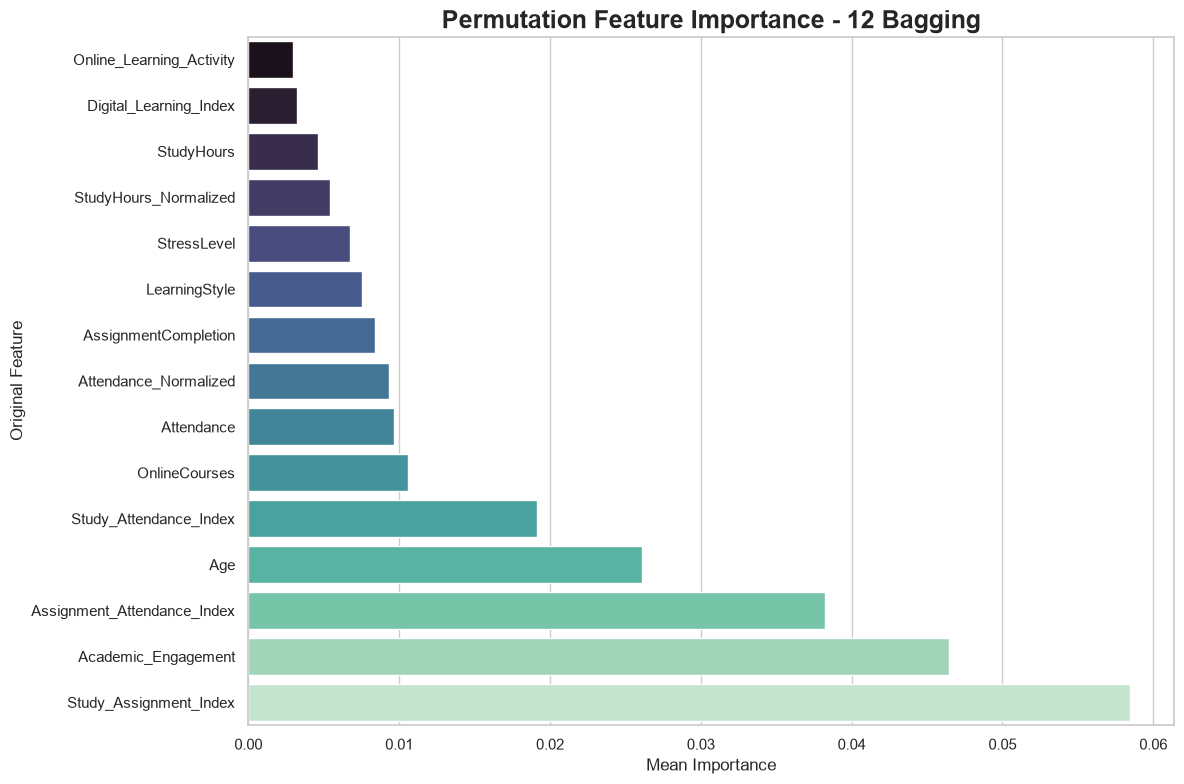

In [72]:
top_permutation=permutation_df.head(15).sort_values("Importance_Mean")
title=f"Permutation Feature Importance - {best_tuned_name}"
plt.figure(figsize=(12,8)); sns.barplot(data=top_permutation,x="Importance_Mean",y="Feature",hue="Feature",palette="mako",legend=False)
plt.xlabel("Mean Importance"); plt.ylabel("Original Feature")
save_plot(title)

In [73]:
if feature_importance_df is not None: feature_importance_df.to_csv("artifacts/native_feature_importance.csv",index=False)
permutation_df.to_csv("artifacts/permutation_feature_importance.csv",index=False)
print("Feature importance files saved.")

Feature importance files saved.


In [74]:
def get_class_probabilities(model,data):
    if hasattr(model,"predict_proba"):
        p=model.predict_proba(data); return model.classes_,p
    if hasattr(model,"decision_function"):
        d=np.asarray(model.decision_function(data)); d=np.atleast_2d(d)
        d=d-d.max(axis=1,keepdims=True); p=np.exp(d); p=p/p.sum(axis=1,keepdims=True); return model.classes_,p
    return None,None

In [75]:
def predict_student(student_data,model=final_model):
    student_df=pd.DataFrame([student_data])
    missing=[c for c in X.columns if c not in student_df.columns]
    extra=[c for c in student_df.columns if c not in X.columns]
    if missing: raise ValueError(f"Missing features: {missing}")
    if extra: raise ValueError(f"Unexpected features: {extra}")
    student_df=student_df[X.columns]
    prediction=model.predict(student_df)[0]
    classes,probs=get_class_probabilities(model,student_df)
    if probs is not None:
        probability_df=pd.DataFrame({"FinalGrade_Class":classes,"Probability":probs[0]*100}).sort_values("Probability",ascending=False).reset_index(drop=True)
        confidence=float(probability_df.iloc[0]["Probability"])
    else:
        probability_df=None; confidence=None
    return {"Predicted_FinalGrade":prediction,"Class_Probabilities":probability_df,"Confidence":confidence}

In [76]:
example_student={"Academic_Engagement":75,"Assignment_Attendance_Index":80,"Study_Assignment_Index":72,"Study_Attendance_Index":78,"AssignmentCompletion":85,"Attendance_Normalized":.85,"Age":20,"Attendance":85,"StudyHours":4,"OnlineCourses":3,"StudyHours_Normalized":.67,"LearningStyle":"Visual","Motivation_Study_Index":78,"StressLevel":"Low","Online_Learning_Activity":70,"Participation_Rate":80,"Digital_Learning_Index":75,"Motivation":"High"}

In [77]:
prediction_result=predict_student(example_student)
print("Predicted FinalGrade:",prediction_result["Predicted_FinalGrade"])
print("Confidence:",prediction_result["Confidence"])
display(prediction_result["Class_Probabilities"].style.format({"Probability":"{:.2f}%"}))

Predicted FinalGrade: 1
Confidence: 30.0


,FinalGrade_Class,Probability
0,1,30.00%
1,0,25.00%
2,3,25.00%
3,2,20.00%


Saved: image\student_finalgrade_class_probabilities.png


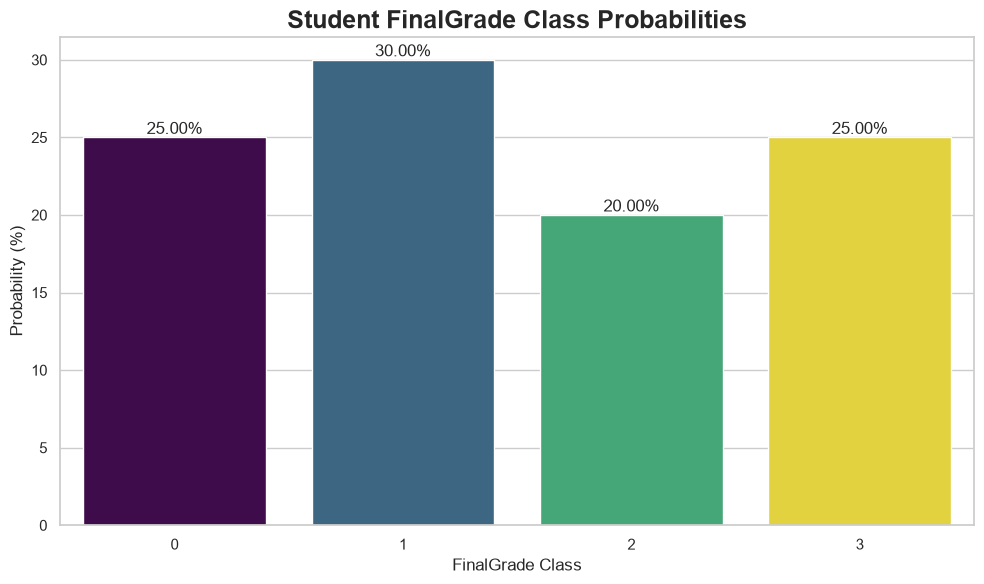

In [78]:
probability_df=prediction_result["Class_Probabilities"]
title="Student FinalGrade Class Probabilities"
plt.figure(figsize=(10,6)); ax=sns.barplot(data=probability_df,x="FinalGrade_Class",y="Probability",hue="FinalGrade_Class",palette="viridis",legend=False)
for c in ax.containers: ax.bar_label(c,fmt="%.2f%%")
plt.xlabel("FinalGrade Class"); plt.ylabel("Probability (%)")
save_plot(title)

In [79]:
final_model_path="artifacts/final_edupredict_model.pkl"
joblib.dump(final_model,final_model_path)
print("Saved:",final_model_path)

Saved: artifacts/final_edupredict_model.pkl


In [80]:
feature_list_path="artifacts/feature_columns.pkl"
joblib.dump(X.columns.tolist(),feature_list_path)
print("Saved:",feature_list_path)

Saved: artifacts/feature_columns.pkl


In [81]:
final_metrics_df.to_csv("artifacts/final_test_metrics.csv",index=False)
per_class_df.to_csv("artifacts/per_class_metrics.csv")
print("Final metrics saved.")

Final metrics saved.


In [82]:
pd.DataFrame({"FinalGrade_Class":sorted(y.unique())}).to_csv("artifacts/finalgrade_classes.csv",index=False)
print("Saved: artifacts/finalgrade_classes.csv")

Saved: artifacts/finalgrade_classes.csv


In [83]:
print("="*80); print("EDUPREDICT AI — FINAL MODEL SUMMARY"); print("="*80)
print(f"Dataset Records: {len(df):,}")
print(f"Input Features: {X.shape[1]}")
print(f"Target: {target}")
print(f"Classes: {sorted(y.unique())}")
print("Models Evaluated: 20")
print("Final Model:",best_tuned_name)
print("Best CV Macro F1:",round(best_tuned_cv_score,4))
print("Final Test Metrics:")
for k,v in final_metrics.items(): print(f"{k}: {v:.4f}")
print("Saved Model:",final_model_path)
print("="*80)

EDUPREDICT AI — FINAL MODEL SUMMARY
Dataset Records: 12,469
Input Features: 18
Target: FinalGrade
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Models Evaluated: 20
Final Model: 12 Bagging
Best CV Macro F1: 0.8639
Final Test Metrics:
Accuracy: 0.9118
Precision Macro: 0.9126
Recall Macro: 0.9112
F1 Macro: 0.9118
Precision Weighted: 0.9120
Recall Weighted: 0.9118
F1 Weighted: 0.9118
Saved Model: artifacts/final_edupredict_model.pkl


In [84]:
comparison_final=cv_results_df.merge(model_results_df,on="Model",how="left").sort_values("F1_Macro_Mean",ascending=False)
display(comparison_final)

,Model,Accuracy_Mean,Accuracy_STD,F1_Macro_Mean,F1_Macro_STD,F1_Weighted_Mean,F1_Weighted_STD,Precision_Macro_Mean,Recall_Macro_Mean,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted
0,12 Bagging,0.862456,0.006103,0.862336,0.006241,0.862416,0.006107,0.863496,0.861725,0.863158,0.864907,0.861676,0.862734,0.863941,0.863158,0.863007
1,08 Extra Trees,0.861955,0.007212,0.861898,0.007247,0.861918,0.007200,0.862741,0.861529,0.870677,0.871619,0.869719,0.870372,0.871105,0.870677,0.870603
2,07 Random Forest,0.861855,0.005747,0.861614,0.005698,0.861821,0.005742,0.862133,0.861337,0.859649,0.860418,0.858895,0.859363,0.860113,0.859649,0.859602
3,06 Decision Tree,0.813835,0.014349,0.813553,0.014515,0.813880,0.014343,0.813427,0.813895,0.830576,0.832130,0.829246,0.830243,0.831387,0.830576,0.830543
4,10 HistGradientBoosting,0.809223,0.006193,0.808973,0.005780,0.809164,0.006132,0.810783,0.808070,0.822055,0.823732,0.820587,0.821586,0.822864,0.822055,0.821900
5,18 LightGBM,0.803108,0.008862,0.802863,0.008812,0.803035,0.008835,0.804863,0.801868,0.802506,0.805009,0.800846,0.802156,0.803673,0.802506,0.802332
6,20 XGBoost,0.779749,0.009973,0.779445,0.009622,0.779659,0.009860,0.782197,0.778209,0.785464,0.787200,0.783420,0.784597,0.786458,0.785464,0.785263
7,19 CatBoost,0.568421,0.017436,0.564819,0.016243,0.566375,0.016572,0.576397,0.563649,0.556391,0.559492,0.551891,0.552429,0.558730,0.556391,0.554335
8,17 MLP Neural Network,0.502556,0.024381,0.500111,0.024608,0.501653,0.024475,0.502057,0.500164,0.433083,0.431059,0.430351,0.430264,0.432206,0.433083,0.432210
9,09 Gradient Boosting,0.490526,0.010870,0.485108,0.010200,0.487260,0.010152,0.495742,0.485347,0.487218,0.487762,0.482362,0.481971,0.487681,0.487218,0.484372


In [85]:
comparison_final.to_csv("artifacts/complete_20_model_comparison.csv",index=False)
print("Saved: artifacts/complete_20_model_comparison.csv")

Saved: artifacts/complete_20_model_comparison.csv


In [86]:
print(f"The selected model is {best_tuned_name} based on cross-validated Macro F1 after GridSearchCV.")
print("The final 20% test set was reserved for final evaluation after model selection.")
print("The system predicts FinalGrade classes 0, 1, 2, and 3.")
print("An exact exam percentage is not produced because ExamScore is not a valid target in this dataset.")

The selected model is 12 Bagging based on cross-validated Macro F1 after GridSearchCV.
The final 20% test set was reserved for final evaluation after model selection.
The system predicts FinalGrade classes 0, 1, 2, and 3.
An exact exam percentage is not produced because ExamScore is not a valid target in this dataset.
